# メインプレフィックス比較

対象は、**IPv4全トラフィック**、**native** の選択済みプレフィックスmembership、およびRaw由来の固定プレフィックス集合です。**Raw** と **Broad** の条件で比較します。canonical `src_ip` と `dst_ip` は最初に観測した方向を保持しており、initiator/responderの役割を表しません。

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
from matplotlib import font_manager

japanese_font_candidates = ('Hiragino Sans', 'Noto Sans CJK JP', 'Noto Serif CJK JP', 'IPAexGothic', 'YuGothic', 'Meiryo')
available_font_names = {font.name for font in font_manager.fontManager.ttflist}
japanese_font = next((font for font in japanese_font_candidates if font in available_font_names), None)
if japanese_font is None:
    raise RuntimeError('日本語グリフを含むMatplotlibフォントが見つかりません')
plt.rcParams['font.family'] = japanese_font
plt.rcParams['axes.unicode_minus'] = False
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D

from mawi_global_analysis.comparison import build_comparison_flow_inclusion
from mawi_global_analysis.io import load_run

def resolve_analysis_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'src' / 'mawi_global_analysis').is_dir():
            return candidate
    return Path.cwd()

root = Path(os.environ.get('MAWI_ANALYSIS_ROOT', resolve_analysis_root())).resolve()
dataset_id = os.environ.get('MAWI_DATASET_ID', 'fixture')
run_name = os.environ.get('MAWI_RUN_NAME', 'baseline')
run = load_run(dataset_id, run_name, root=root)
condition_display_names = {'Raw': 'Raw（除外前）', 'Broad': 'Broad（除外後）'}
display_column_names = {'condition': '条件', 'flow_count': 'フロー数', 'packet_count': 'パケット数', 'frame_byte_count': 'フレームバイト数', 'ip_byte_count': 'IPバイト数', 'duration': '継続時間', 'median_packet_count': 'パケット数の中央値', 'median_frame_byte_count': 'フレームバイト数の中央値', 'median_duration': '継続時間の中央値', 'q90_duration': '継続時間の90パーセンタイル', 'q99_duration': '継続時間の99パーセンタイル', 'analysis_prefix': '分析プレフィックス', 'prefix': 'プレフィックス', 'prefix_length': 'プレフィックス長', 'seen_as_src_prefix': 'srcプレフィックスとして観測', 'seen_as_dst_prefix': 'dstプレフィックスとして観測', 'removed_flow_count': '除外フロー数', 'removed_flow_ratio': '除外フロー率', 'removed_packet_count': '除外パケット数', 'removed_packet_ratio': '除外パケット率', 'removed_frame_byte_count': '除外フレームバイト数', 'removed_frame_byte_ratio': '除外フレームバイト率', 'raw_selected_native_prefix_count': 'Raw選択済みnativeプレフィックス数', 'raw_table_prefix_count': 'Raw表のプレフィックス数', 'broad_table_prefix_count': 'Broad表のプレフィックス数', 'broad_zero_surviving_prefix_count': 'Broadで生存フローがゼロのプレフィックス数', 'raw_overall_flow_count': 'Raw全体フロー数', 'broad_overall_flow_count': 'Broad全体フロー数'}

def display_table(frame):
    rendered = frame.rename(columns=display_column_names).copy()
    if '条件' in rendered:
        rendered['条件'] = rendered['条件'].map(condition_display_names).fillna(rendered['条件'])
    display(rendered)

provenance = pd.DataFrame([{'データセット': dataset_id, '実行名': run_name, '分析対象': 'IPv4全体 / nativeプレフィックス / Raw-Broad', '設定ハッシュ': run.manifest.get('config', {}).get('hash'), '入力SHA-256': run.manifest.get('input', {}).get('sha256'), 'Gitコミット': run.manifest.get('git_commit')}])
display(provenance)

,データセット,実行名,分析対象,設定ハッシュ,入力SHA-256,Gitコミット
0,202604081400,scan_source_driven_removal,IPv4全体 / nativeプレフィックス / Raw-Broad,2268881f56ad09c5588e4b8e65db953f33f0f451ae2e6c...,5869ff3cd1b8cbe247def8c50fc5eb0d5d0c8df84222d3...,7bf5f988babdaf7928e73fa11cc29dd9fdba83dc


## 正規テーブルの導出

以下のすべての表示は、canonical `flows.csv`、M5で生成されたrun-localの `flow_labels.csv`、Raw由来の固定プレフィックスledger、および固定された `flow_prefix_membership.csv` からこのNotebook内で導出します。plot専用のpipelineデータは読みません。IPv4全体の対象を選ぶ前に、完全なcanonical flow/label集合へM6-A inclusion APIを適用します。

In [2]:
# 完全なcanonical flow集合に対して判断を構築し、M6-A検証の前にflowを絞り込まない。
inclusion = build_comparison_flow_inclusion(run.flows, run.labels)
flow_metrics = run.flows.merge(inclusion, on='flow_id', how='inner', validate='one_to_one')
ipv4_flows = flow_metrics.loc[pd.to_numeric(flow_metrics['ip_version']) == 4]
raw_flows = ipv4_flows
selected_prefixes = run.prefixes.loc[run.prefixes['selected_for_analysis'] == True, ['prefix', 'prefix_length', 'seen_as_src_prefix', 'seen_as_dst_prefix']].copy()
native_membership = run.membership.loc[run.membership['analysis_scope'] == 'native'].copy()
selected_prefix_ids = set(selected_prefixes['prefix'])
if not set(native_membership['flow_id']).issubset(set(inclusion['flow_id'])):
    raise ValueError('native membershipにcanonical flow集合の外部のflow_idが含まれています')
if not set(native_membership['analysis_prefix']).issubset(selected_prefix_ids):
    raise ValueError('native membershipに固定Raw由来選択集合の外部のprefixが含まれています')
prefix_flow_columns = ['flow_id', 'packet_count', 'frame_byte_count', 'ip_byte_count', 'duration', 'raw_included', 'strict_included', 'broad_included']
prefix_flows = native_membership.merge(ipv4_flows.loc[:, prefix_flow_columns], on='flow_id', how='inner', validate='many_to_one')
selected_scope_flows = raw_flows.loc[raw_flows['flow_id'].isin(native_membership['flow_id'].unique())]
display(pd.DataFrame([{'IPv4 Rawフロー数': len(raw_flows), '選択済みnativeプレフィックス数': len(selected_prefixes), 'native membership行数': len(native_membership), 'いずれかのnativeプレフィックスに一致する一意なフロー数': native_membership['flow_id'].nunique()}]))
display_table(selected_prefixes.sort_values('prefix').head(20))

,IPv4 Rawフロー数,選択済みnativeプレフィックス数,native membership行数,いずれかのnativeプレフィックスに一致する一意なフロー数
0,33295132,18,550289,549990


,プレフィックス,プレフィックス長,srcプレフィックスとして観測,dstプレフィックスとして観測
6,131.142.206.160/32,32,False,True
7,131.142.238.168/32,32,False,True
11,133.132.116.53/32,32,True,False
16,142.11.234.5/32,32,True,False
23,150.217.137.141/32,32,True,False
24,150.217.140.38/32,32,True,False
27,151.34.117.44/32,32,True,False
30,157.53.116.0/28,28,False,True
31,157.53.116.16/28,28,False,True
32,157.53.44.81/32,32,True,False


## Raw / Broad 比較表

これらは比較用の表です。すべての条件で同じRaw由来nativeプレフィックス集合とmembershipを保持します。比較可視化はM6-B2で行います。

In [3]:
conditions = pd.DataFrame({'condition': ['Raw', 'Broad'], 'inclusion_column': ['raw_included', 'broad_included']})
count_columns = ['flow_count', 'packet_count', 'frame_byte_count']

def condition_metrics(frame, condition, inclusion_column):
    survivors = frame.loc[frame[inclusion_column]]
    return {'condition': condition, 'flow_count': len(survivors), 'packet_count': survivors['packet_count'].sum(), 'frame_byte_count': survivors['frame_byte_count'].sum(), 'median_packet_count': survivors['packet_count'].median(), 'median_frame_byte_count': survivors['frame_byte_count'].median(), 'median_duration': survivors['duration'].median()}

def safe_ratio(numerator, denominator):
    return numerator.div(denominator.where(denominator > 0))

overall_condition_summary = pd.DataFrame([condition_metrics(ipv4_flows, row.condition, row.inclusion_column) for row in conditions.itertuples(index=False)])
raw_overall = overall_condition_summary.loc[overall_condition_summary['condition'] == 'Raw'].iloc[0]
overall_removal_rows = []
for row in overall_condition_summary.loc[overall_condition_summary['condition'] == 'Broad'].itertuples(index=False):
    overall_removal_rows.append({'condition': row.condition, 'removed_flow_count': raw_overall.flow_count - row.flow_count, 'removed_flow_ratio': (raw_overall.flow_count - row.flow_count) / raw_overall.flow_count if raw_overall.flow_count else np.nan, 'removed_packet_count': raw_overall.packet_count - row.packet_count, 'removed_packet_ratio': (raw_overall.packet_count - row.packet_count) / raw_overall.packet_count if raw_overall.packet_count else np.nan, 'removed_frame_byte_count': raw_overall.frame_byte_count - row.frame_byte_count, 'removed_frame_byte_ratio': (raw_overall.frame_byte_count - row.frame_byte_count) / raw_overall.frame_byte_count if raw_overall.frame_byte_count else np.nan})
overall_removal_summary = pd.DataFrame(overall_removal_rows)

prefix_condition_index = selected_prefixes.loc[:, ['prefix']].rename(columns={'prefix': 'analysis_prefix'}).merge(conditions.loc[:, ['condition', 'inclusion_column']], how='cross')
prefix_condition_metrics = []
for row in conditions.itertuples(index=False):
    survivors = prefix_flows.loc[prefix_flows[row.inclusion_column]]
    metrics = survivors.groupby('analysis_prefix', as_index=False).agg(flow_count=('flow_id', 'size'), packet_count=('packet_count', 'sum'), frame_byte_count=('frame_byte_count', 'sum'), median_packet_count=('packet_count', 'median'), median_frame_byte_count=('frame_byte_count', 'median'), median_duration=('duration', 'median'))
    metrics['condition'] = row.condition
    prefix_condition_metrics.append(metrics)
per_prefix_condition_summary = prefix_condition_index.drop(columns='inclusion_column').merge(pd.concat(prefix_condition_metrics, ignore_index=True), on=['analysis_prefix', 'condition'], how='left', validate='one_to_one')
per_prefix_condition_summary.loc[:, count_columns] = per_prefix_condition_summary.loc[:, count_columns].fillna(0)

raw_prefix_metrics = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == 'Raw', ['analysis_prefix', *count_columns]].rename(columns={column: f'raw_{column}' for column in count_columns})
per_prefix_removal_rows = []
for condition in ['Broad']:
    survivors = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == condition, ['analysis_prefix', *count_columns]]
    comparison = raw_prefix_metrics.merge(survivors, on='analysis_prefix', how='left', validate='one_to_one')
    per_prefix_removal_rows.append(pd.DataFrame({'analysis_prefix': comparison['analysis_prefix'], 'condition': condition, 'removed_flow_count': comparison['raw_flow_count'] - comparison['flow_count'], 'removed_flow_ratio': safe_ratio(comparison['raw_flow_count'] - comparison['flow_count'], comparison['raw_flow_count']), 'removed_packet_count': comparison['raw_packet_count'] - comparison['packet_count'], 'removed_packet_ratio': safe_ratio(comparison['raw_packet_count'] - comparison['packet_count'], comparison['raw_packet_count']), 'removed_frame_byte_count': comparison['raw_frame_byte_count'] - comparison['frame_byte_count'], 'removed_frame_byte_ratio': safe_ratio(comparison['raw_frame_byte_count'] - comparison['frame_byte_count'], comparison['raw_frame_byte_count'])}))
per_prefix_removal_summary = pd.concat(per_prefix_removal_rows, ignore_index=True)

strict_overall_count = int(ipv4_flows['strict_included'].sum())
broad_overall_count = int(ipv4_flows['broad_included'].sum())
raw_overall_count = int(ipv4_flows['raw_included'].sum())
if not (broad_overall_count <= strict_overall_count <= raw_overall_count):
    raise ValueError('内部除外不変条件 Broad <= Strict <= Raw に違反しています')
overall_counts = overall_condition_summary.set_index('condition')['flow_count']
prefix_counts_by_condition = per_prefix_condition_summary.groupby('condition')['analysis_prefix'].nunique().reindex(conditions['condition'])
if not (overall_counts['Broad'] <= overall_counts['Raw']):
    raise ValueError('全体の生存フロー数が Broad <= Raw に違反しています')
if not (prefix_counts_by_condition == len(selected_prefixes)).all():
    raise ValueError('比較条件が完全な固定Raw由来プレフィックス集合を保持していません')
for condition in conditions['condition']:
    condition_prefixes = set(per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == condition, 'analysis_prefix'])
    if condition_prefixes != selected_prefix_ids:
        raise ValueError('比較条件が固定Raw由来プレフィックス集合を変更しています')
sanity_summary = pd.DataFrame([{'raw_selected_native_prefix_count': len(selected_prefixes), 'raw_table_prefix_count': prefix_counts_by_condition['Raw'], 'broad_table_prefix_count': prefix_counts_by_condition['Broad'], 'broad_zero_surviving_prefix_count': int((per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == 'Broad', 'flow_count'] == 0).sum()), 'raw_overall_flow_count': overall_counts['Raw'], 'broad_overall_flow_count': overall_counts['Broad']}])

display_table(overall_condition_summary)
display_table(overall_removal_summary)
display_table(per_prefix_condition_summary.sort_values(['condition', 'analysis_prefix']))
display_table(per_prefix_removal_summary.sort_values(['condition', 'analysis_prefix']))
display_table(sanity_summary)

,条件,フロー数,パケット数,フレームバイト数,パケット数の中央値,フレームバイト数の中央値,継続時間の中央値
0,Raw（除外前）,33295132,189938960,10293558638,1.0,58.0,0.0
1,Broad（除外後）,15222973,151529952,7946071142,1.0,58.0,0.0


,条件,除外フロー数,除外フロー率,除外パケット数,除外パケット率,除外フレームバイト数,除外フレームバイト率
0,Broad（除外後）,18072159,0.542787,38409008,0.202218,2347487496,0.228054


,分析プレフィックス,条件,フロー数,パケット数,フレームバイト数,パケット数の中央値,フレームバイト数の中央値,継続時間の中央値
1,131.142.206.160/32,Broad（除外後）,898,2031684,97590112,10.0,498.0,0.331564
3,131.142.238.168/32,Broad（除外後）,8010,3558354,155021232,9.0,498.0,1.486954
5,133.132.116.53/32,Broad（除外後）,38872,3585431,176006630,14.0,630.0,0.674773
7,142.11.234.5/32,Broad（除外後）,471,38449,1737838,37.0,1666.0,0.465926
9,150.217.137.141/32,Broad（除外後）,50017,5516958,354130716,11.0,742.0,1.170809
11,150.217.140.38/32,Broad（除外後）,17,25,1306,1.0,66.0,0.000000
13,151.34.117.44/32,Broad（除外後）,1818,956794,63168304,73.5,4859.0,3.368901
15,157.53.116.0/28,Broad（除外後）,44661,6188868,315357360,9.0,504.0,0.599327
17,157.53.116.16/28,Broad（除外後）,15929,4470043,216513198,8.0,436.0,0.381309
19,157.53.44.81/32,Broad（除外後）,465,2866929,189220534,6604.0,435864.0,6.209449


,分析プレフィックス,条件,除外フロー数,除外フロー率,除外パケット数,除外パケット率,除外フレームバイト数,除外フレームバイト率
0,131.142.206.160/32,Broad（除外後）,96,0.096579,1690,0.000831,94000,0.000962
1,131.142.238.168/32,Broad（除外後）,791,0.089876,37705,0.010485,2113662,0.013451
2,133.132.116.53/32,Broad（除外後）,62308,0.615813,1783411,0.332178,117569098,0.400473
3,142.11.234.5/32,Broad（除外後）,121,0.204392,1035874,0.964211,69201652,0.975503
4,150.217.137.141/32,Broad（除外後）,6443,0.114116,1727629,0.238472,109779354,0.236639
5,150.217.140.38/32,Broad（除外後）,42,0.711864,42,0.626866,2432,0.650615
6,151.34.117.44/32,Broad（除外後）,1,0.000550,119,0.000124,7862,0.000124
7,157.53.116.0/28,Broad（除外後）,23790,0.347548,450333,0.067829,28420194,0.082670
8,157.53.116.16/28,Broad（除外後）,8948,0.359690,195342,0.041870,12659588,0.055240
9,157.53.44.81/32,Broad（除外後）,0,0.000000,0,0.000000,0,0.000000


,Raw選択済みnativeプレフィックス数,Raw表のプレフィックス数,Broad表のプレフィックス数,Broadで生存フローがゼロのプレフィックス数,Raw全体フロー数,Broad全体フロー数
0,18,18,18,0,33295132,15222973


## Raw / Broad 比較の可視化

これらの図は、作成済みの比較表における変化を示します。flowの再分類や固定Raw由来プレフィックス集合の変更は行いません。

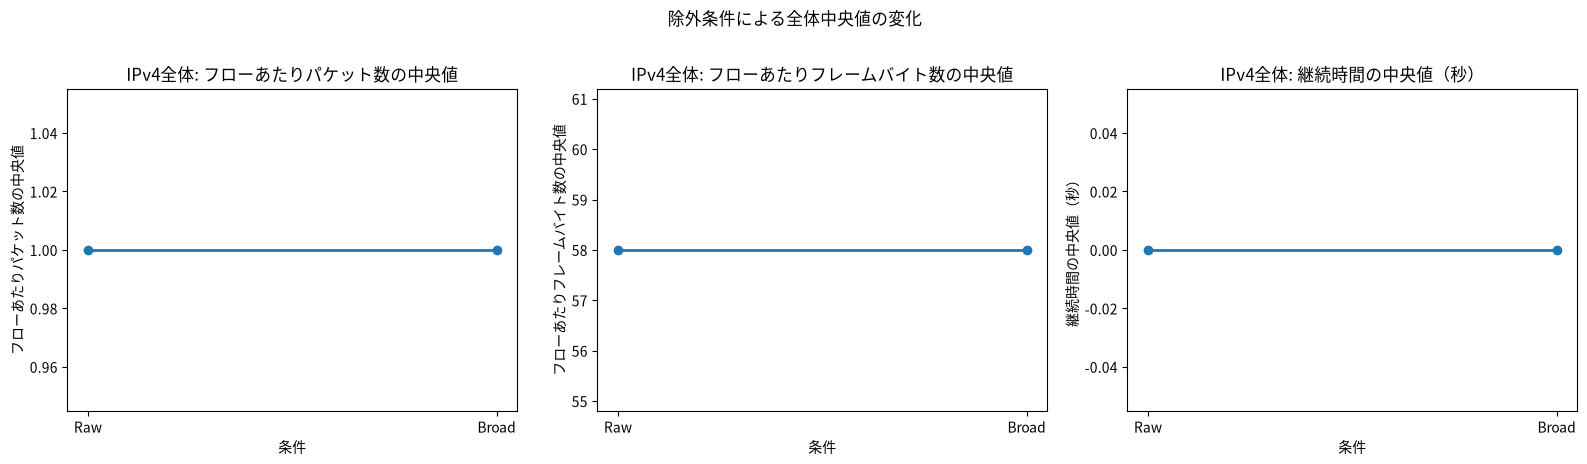

In [4]:
condition_order = ['Raw', 'Broad']
condition_labels = condition_display_names
median_metrics = ['median_packet_count', 'median_frame_byte_count', 'median_duration']
metric_labels = {'median_packet_count': 'フローあたりパケット数の中央値', 'median_frame_byte_count': 'フローあたりフレームバイト数の中央値', 'median_duration': '継続時間の中央値（秒）'}
overall_medians = overall_condition_summary.set_index('condition').reindex(condition_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for axis, metric in zip(axes, median_metrics):
    axis.plot(condition_order, overall_medians[metric], marker='o', linewidth=2, color='tab:blue')
    axis.set(title=f'IPv4全体: {metric_labels[metric]}', xlabel='条件', ylabel=metric_labels[metric])
fig.suptitle('除外条件による全体中央値の変化', y=1.02)
fig.tight_layout()

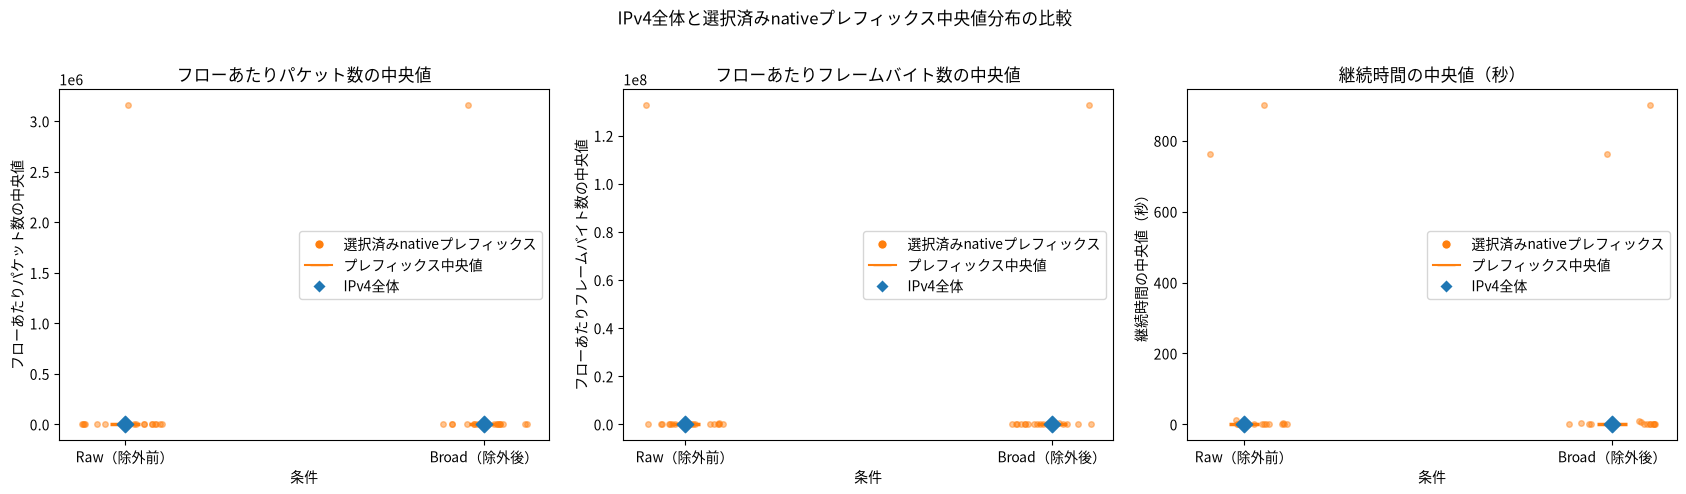

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
jitter = np.random.default_rng(0)
for axis, metric in zip(axes, median_metrics):
    for position, condition in enumerate(condition_order):
        values = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == condition, metric].dropna()
        axis.scatter(position + jitter.uniform(-0.12, 0.12, len(values)), values, s=16, alpha=0.45, color='tab:orange', label='選択済みnativeプレフィックス' if position == 0 else None)
        if not values.empty:
            axis.scatter(position, values.median(), marker='_', s=450, linewidths=2.5, color='tab:orange', zorder=2, label='プレフィックス中央値' if position == 0 else None)
        axis.scatter(position, overall_medians.loc[condition, metric], marker='D', s=70, color='tab:blue', zorder=3, label='IPv4全体' if position == 0 else None)
    axis.set(title=metric_labels[metric], xlabel='条件', ylabel=metric_labels[metric], xticks=range(len(condition_order)), xticklabels=[condition_labels[condition] for condition in condition_order])
    axis.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=7, label='選択済みnativeプレフィックス'), Line2D([0], [0], marker='_', color='tab:orange', markersize=13, label='プレフィックス中央値'), Line2D([0], [0], marker='D', color='w', markerfacecolor='tab:blue', markersize=7, label='IPv4全体')])
fig.suptitle('IPv4全体と選択済みnativeプレフィックス中央値分布の比較', y=1.02)
fig.tight_layout()

### Broad除外によるプレフィックス別中央値の変化

固定された選択済みnative `analysis_prefix` ごとに、既存のRaw / Broad集計を比較します。RawまたはBroadで生存flowがなく中央値が定義できないプレフィックスは、中央値変化の図から除外します。packet_countとframe_byte_countのRaw中央値が0の場合は変化率を`NaN`とし、durationはゼロ除算を避けるため絶対差（秒）で示します。

,analysis_prefix,raw_flow_count,broad_flow_count,flow_removal_rate,raw_median_packet_count,broad_median_packet_count,packet_change_rate,raw_median_frame_byte_count,broad_median_frame_byte_count,frame_byte_change_rate,raw_median_duration,broad_median_duration,duration_delta
0,131.142.206.160/32,994,898,9.657948,10.0,10.0,0.000000,498.0,498.0,0.000000,0.413736,0.331564,-0.082172
1,131.142.238.168/32,8801,8010,8.987615,10.0,9.0,-10.000000,528.0,498.0,-5.681818,1.718025,1.486954,-0.231071
2,133.132.116.53/32,101180,38872,61.581340,13.0,14.0,7.692308,804.0,630.0,-21.641791,1.201265,0.674773,-0.526492
3,142.11.234.5/32,592,471,20.439189,33.0,37.0,12.121212,1638.0,1666.0,1.709402,0.430655,0.465926,0.035271
4,150.217.137.141/32,56460,50017,11.411619,11.0,11.0,0.000000,742.0,742.0,0.000000,1.395999,1.170809,-0.225190
5,150.217.140.38/32,59,17,71.186441,1.0,1.0,0.000000,58.0,66.0,13.793103,0.000000,0.000000,0.000000
6,151.34.117.44/32,1819,1818,0.054975,74.0,73.5,-0.675676,4892.0,4859.0,-0.674571,3.370416,3.368901,-0.001515
7,157.53.116.0/28,68451,44661,34.754788,9.0,9.0,0.000000,510.0,504.0,-1.176471,0.642715,0.599327,-0.043388
8,157.53.116.16/28,24877,15929,35.968967,8.0,8.0,0.000000,470.0,436.0,-7.234043,0.562915,0.381309,-0.181606
9,157.53.44.81/32,465,465,0.000000,6604.0,6604.0,0.000000,435864.0,435864.0,0.000000,6.209449,6.209449,0.000000


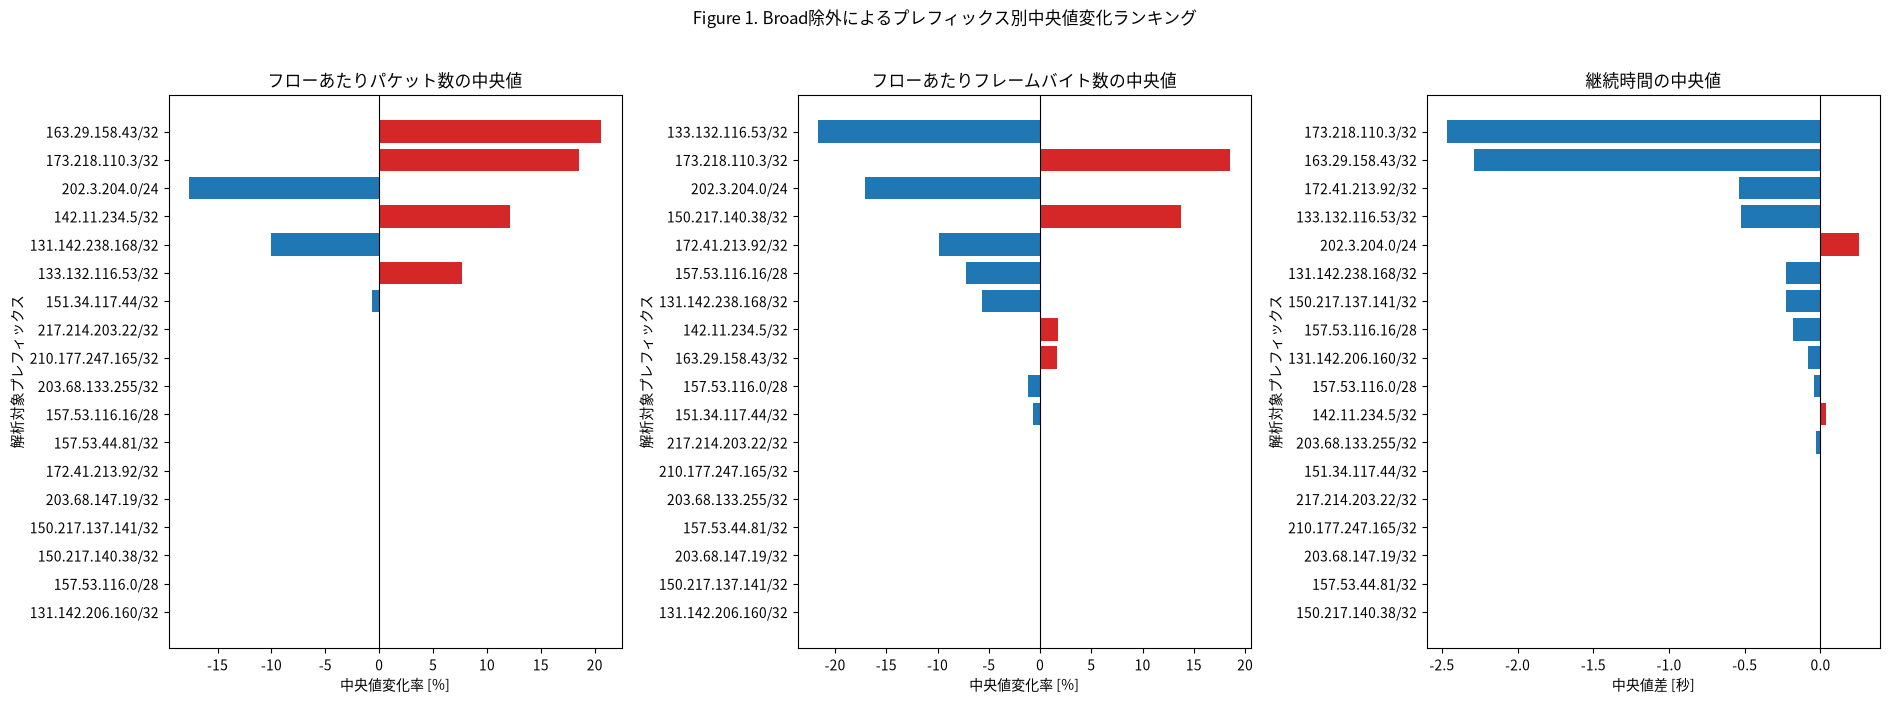

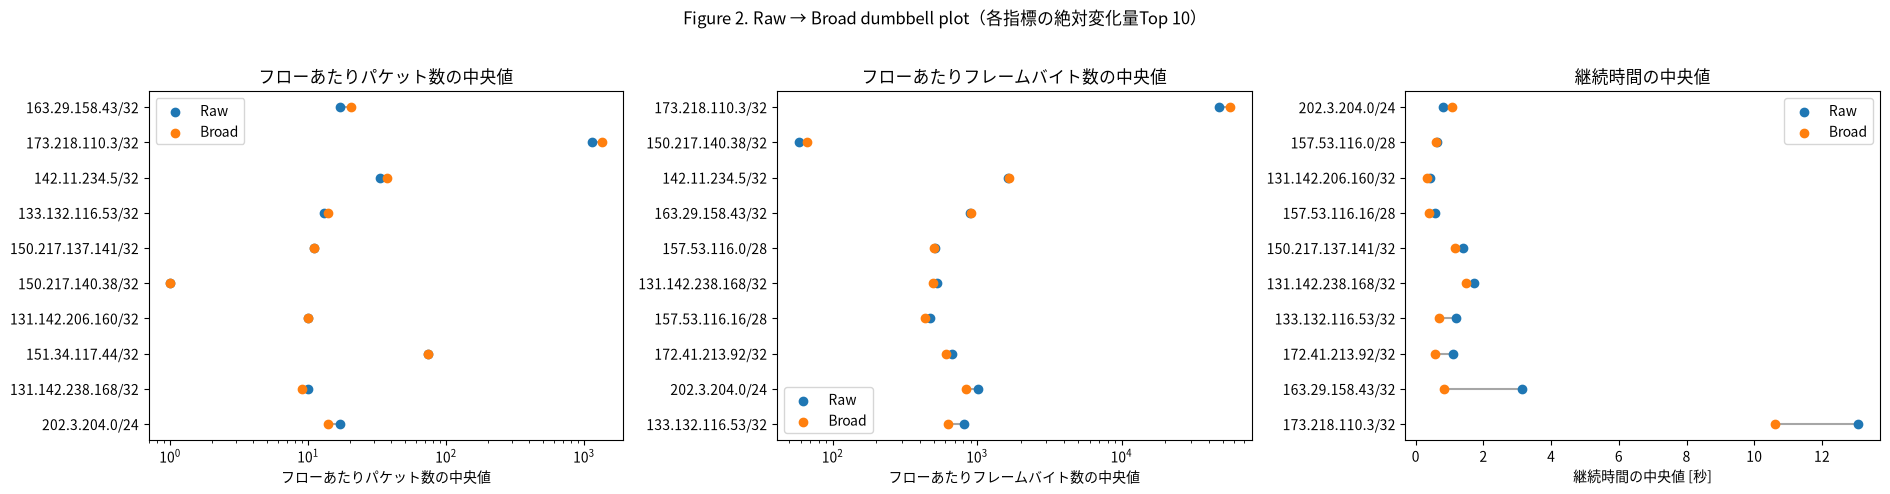

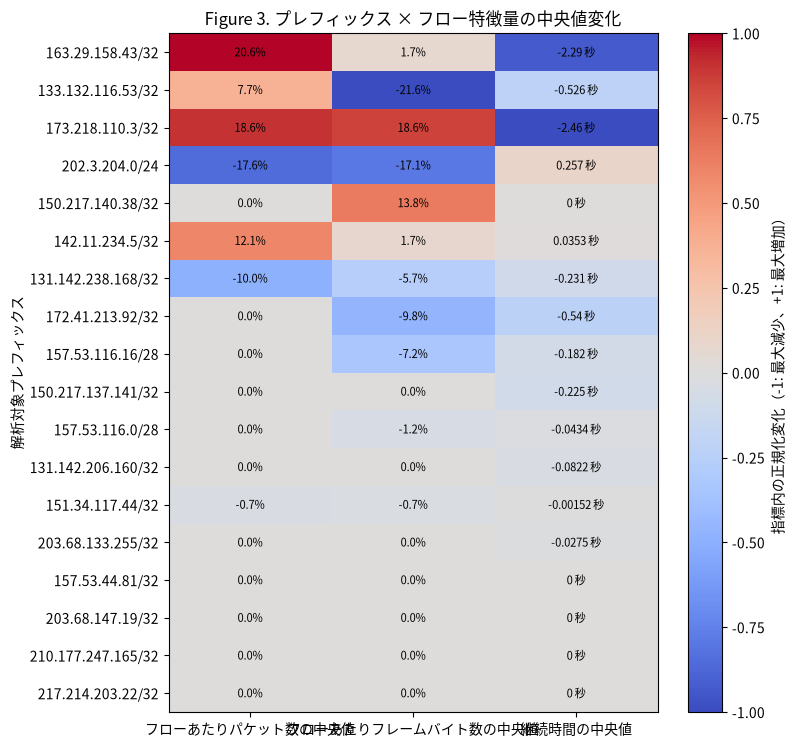

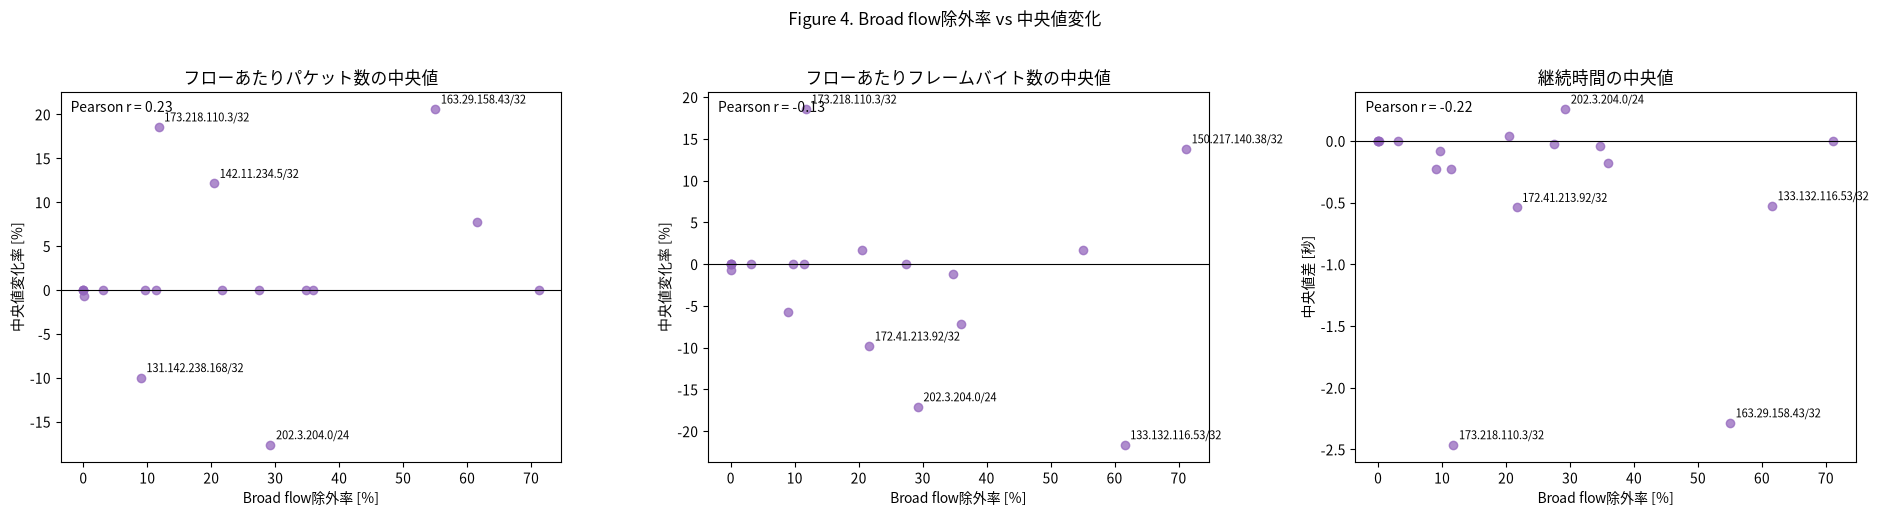

In [6]:
raw_prefix_comparison = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == 'Raw', ['analysis_prefix', 'flow_count', *median_metrics]].rename(columns={'flow_count': 'raw_flow_count', **{metric: f'raw_{metric}' for metric in median_metrics}})
broad_prefix_comparison = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == 'Broad', ['analysis_prefix', 'flow_count', *median_metrics]].rename(columns={'flow_count': 'broad_flow_count', **{metric: f'broad_{metric}' for metric in median_metrics}})
prefix_broad_comparison = raw_prefix_comparison.merge(broad_prefix_comparison, on='analysis_prefix', how='inner', validate='one_to_one')
prefix_broad_comparison['flow_removal_rate'] = safe_ratio(prefix_broad_comparison['raw_flow_count'] - prefix_broad_comparison['broad_flow_count'], prefix_broad_comparison['raw_flow_count']).mul(100)
prefix_broad_comparison['packet_change_rate'] = safe_ratio(prefix_broad_comparison['broad_median_packet_count'] - prefix_broad_comparison['raw_median_packet_count'], prefix_broad_comparison['raw_median_packet_count']).mul(100)
prefix_broad_comparison['frame_byte_change_rate'] = safe_ratio(prefix_broad_comparison['broad_median_frame_byte_count'] - prefix_broad_comparison['raw_median_frame_byte_count'], prefix_broad_comparison['raw_median_frame_byte_count']).mul(100)
prefix_broad_comparison['duration_delta'] = prefix_broad_comparison['broad_median_duration'] - prefix_broad_comparison['raw_median_duration']
comparison_display_columns = ['analysis_prefix', 'raw_flow_count', 'broad_flow_count', 'flow_removal_rate', 'raw_median_packet_count', 'broad_median_packet_count', 'packet_change_rate', 'raw_median_frame_byte_count', 'broad_median_frame_byte_count', 'frame_byte_change_rate', 'raw_median_duration', 'broad_median_duration', 'duration_delta']
display(prefix_broad_comparison.loc[:, comparison_display_columns].sort_values('analysis_prefix'))

change_specs = [
    {'change_column': 'packet_change_rate', 'raw_column': 'raw_median_packet_count', 'broad_column': 'broad_median_packet_count', 'title': 'フローあたりパケット数の中央値', 'change_label': '中央値変化率 [%]', 'value_label': 'フローあたりパケット数の中央値', 'format': lambda value: f'{value:.1f}%'},
    {'change_column': 'frame_byte_change_rate', 'raw_column': 'raw_median_frame_byte_count', 'broad_column': 'broad_median_frame_byte_count', 'title': 'フローあたりフレームバイト数の中央値', 'change_label': '中央値変化率 [%]', 'value_label': 'フローあたりフレームバイト数の中央値', 'format': lambda value: f'{value:.1f}%'},
    {'change_column': 'duration_delta', 'raw_column': 'raw_median_duration', 'broad_column': 'broad_median_duration', 'title': '継続時間の中央値', 'change_label': '中央値差 [秒]', 'value_label': '継続時間の中央値 [秒]', 'format': lambda value: f'{value:.3g} 秒'},
]

# Figure 1: 全選択済みnativeプレフィックスを絶対変化量の大きい順に表示する。
fig, axes = plt.subplots(1, 3, figsize=(19, max(5, len(prefix_broad_comparison) * 0.38)))
for axis, spec in zip(axes, change_specs):
    ranked = prefix_broad_comparison.dropna(subset=[spec['change_column']]).sort_values(spec['change_column'], key=lambda values: values.abs())
    if ranked.empty:
        axis.text(0.5, 0.5, '比較可能なプレフィックス中央値はありません', ha='center', va='center', transform=axis.transAxes)
    else:
        colors = np.where(ranked[spec['change_column']] >= 0, 'tab:red', 'tab:blue')
        axis.barh(ranked['analysis_prefix'], ranked[spec['change_column']], color=colors)
        axis.axvline(0, color='black', linewidth=0.8)
    axis.set(title=spec['title'], xlabel=spec['change_label'], ylabel='解析対象プレフィックス')
fig.suptitle('Figure 1. Broad除外によるプレフィックス別中央値変化ランキング', y=1.02)
fig.tight_layout()

# Figure 2: 各指標で絶対変化量が大きいTop Nについて、RawとBroadの値そのものを結ぶ。
DUMBBELL_TOP_N = 10
fig, axes = plt.subplots(1, 3, figsize=(19, max(4.5, DUMBBELL_TOP_N * 0.48)))
for axis, spec in zip(axes, change_specs):
    paired = prefix_broad_comparison.dropna(subset=[spec['change_column'], spec['raw_column'], spec['broad_column']]).copy()
    paired = paired.loc[paired[spec['change_column']].abs().nlargest(DUMBBELL_TOP_N).index].sort_values(spec['change_column'])
    if paired.empty:
        axis.text(0.5, 0.5, '比較可能なプレフィックス中央値はありません', ha='center', va='center', transform=axis.transAxes)
        continue
    positions = np.arange(len(paired))
    for position, row in enumerate(paired.itertuples(index=False)):
        axis.plot([getattr(row, spec['raw_column']), getattr(row, spec['broad_column'])], [position, position], color='0.65', linewidth=1.5, zorder=1)
    axis.scatter(paired[spec['raw_column']], positions, color='tab:blue', label='Raw', zorder=2)
    axis.scatter(paired[spec['broad_column']], positions, color='tab:orange', label='Broad', zorder=2)
    if spec['title'] != '継続時間の中央値' and (paired[[spec['raw_column'], spec['broad_column']]] > 0).all().all():
        axis.set_xscale('log')
    axis.set(yticks=positions, yticklabels=paired['analysis_prefix'], title=spec['title'], xlabel=spec['value_label'])
    axis.legend()
fig.suptitle(f'Figure 2. Raw → Broad dumbbell plot（各指標の絶対変化量Top {DUMBBELL_TOP_N}）', y=1.02)
fig.tight_layout()

# Figure 3: 色は指標ごとの最大絶対変化で正規化し、annotationは単位付きの生の変化量を示す。
heatmap_values = prefix_broad_comparison.set_index('analysis_prefix')[[spec['change_column'] for spec in change_specs]].copy()
normalizers = heatmap_values.abs().max(axis=0).replace(0, np.nan)
heatmap_strength = heatmap_values.divide(normalizers, axis='columns')
heatmap_order = heatmap_strength.abs().max(axis=1).sort_values(ascending=False).index
heatmap_values = heatmap_values.reindex(heatmap_order)
heatmap_strength = heatmap_strength.reindex(heatmap_order)
fig, axis = plt.subplots(figsize=(8, max(4, len(heatmap_strength) * 0.42)))
image = axis.imshow(heatmap_strength.fillna(0).to_numpy(), cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
for row_index, prefix in enumerate(heatmap_values.index):
    for column_index, spec in enumerate(change_specs):
        value = heatmap_values.iloc[row_index, column_index]
        label = 'NaN' if pd.isna(value) else spec['format'](value)
        axis.text(column_index, row_index, label, ha='center', va='center', fontsize=8)
    
axis.set(xticks=np.arange(len(change_specs)), xticklabels=[spec['title'] for spec in change_specs], yticks=np.arange(len(heatmap_values)), yticklabels=heatmap_values.index, ylabel='解析対象プレフィックス', title='Figure 3. プレフィックス × フロー特徴量の中央値変化')
colorbar = fig.colorbar(image, ax=axis, label='指標内の正規化変化（-1: 最大減少、+1: 最大増加）')
fig.tight_layout()

# Figure 4: Broadのflow除外率と中央値変化を比較し、各指標で変化が大きい点を識別できるようにする。
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for axis, spec in zip(axes, change_specs):
    plotted = prefix_broad_comparison.dropna(subset=['flow_removal_rate', spec['change_column']]).copy()
    axis.scatter(plotted['flow_removal_rate'], plotted[spec['change_column']], color='tab:purple', alpha=0.75)
    axis.axhline(0, color='black', linewidth=0.8)
    if not plotted.empty:
        label_indices = plotted[spec['change_column']].abs().nlargest(min(5, len(plotted))).index
        for row in plotted.loc[label_indices].itertuples(index=False):
            axis.annotate(row.analysis_prefix, (row.flow_removal_rate, getattr(row, spec['change_column'])), xytext=(4, 4), textcoords='offset points', fontsize=8)
        correlation = plotted['flow_removal_rate'].corr(plotted[spec['change_column']])
        if pd.notna(correlation):
            axis.text(0.02, 0.98, f'Pearson r = {correlation:.2f}', ha='left', va='top', transform=axis.transAxes)
    axis.set(title=spec['title'], xlabel='Broad flow除外率 [%]', ylabel=spec['change_label'])
fig.suptitle('Figure 4. Broad flow除外率 vs 中央値変化', y=1.02)
fig.tight_layout()

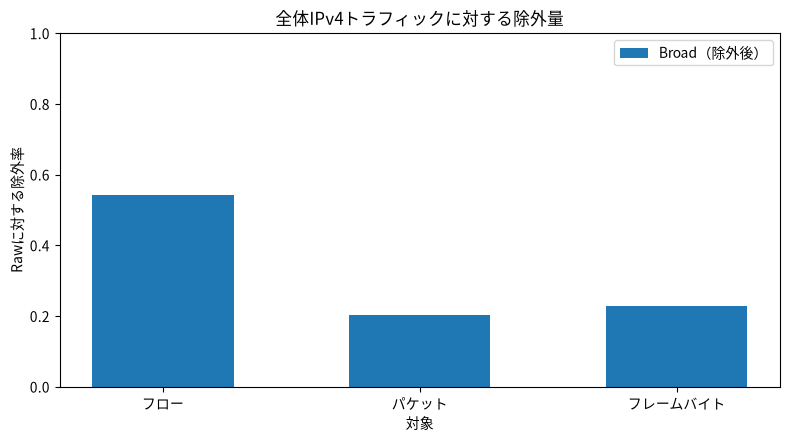

In [7]:
removal_metrics = ['removed_flow_ratio', 'removed_packet_ratio', 'removed_frame_byte_ratio']
removal_labels = ['フロー', 'パケット', 'フレームバイト']
removal_plot = overall_removal_summary.set_index('condition').reindex(['Broad'])
positions = np.arange(len(removal_metrics))
width = 0.55
fig, axis = plt.subplots(figsize=(8, 4.5))
condition = 'Broad'
axis.bar(positions, removal_plot.loc[condition, removal_metrics], width=width, label=condition_labels[condition])
axis.set(title='全体IPv4トラフィックに対する除外量', xlabel='対象', ylabel='Rawに対する除外率', xticks=positions, xticklabels=removal_labels, ylim=(0, 1))
axis.legend()
fig.tight_layout()

## Rawベースラインの記述的分布

Rawのフロー長表示は、ベースラインの記述的な参照として残します。その直後に同じ選択済みnativeプレフィックス集合を使ったBroad除外後の分布を示し、条件間の比較可能性を保ちます。

/tmp/ipykernel_198040/3148014309.py:66: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


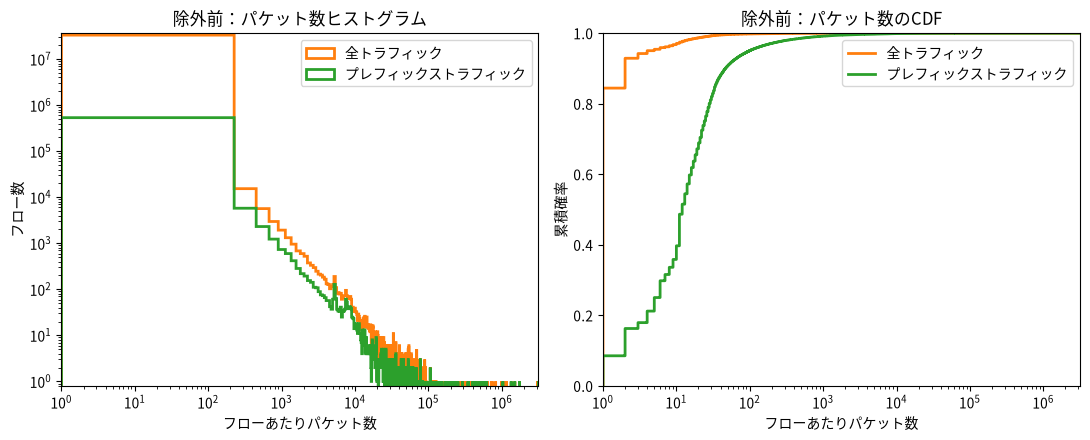

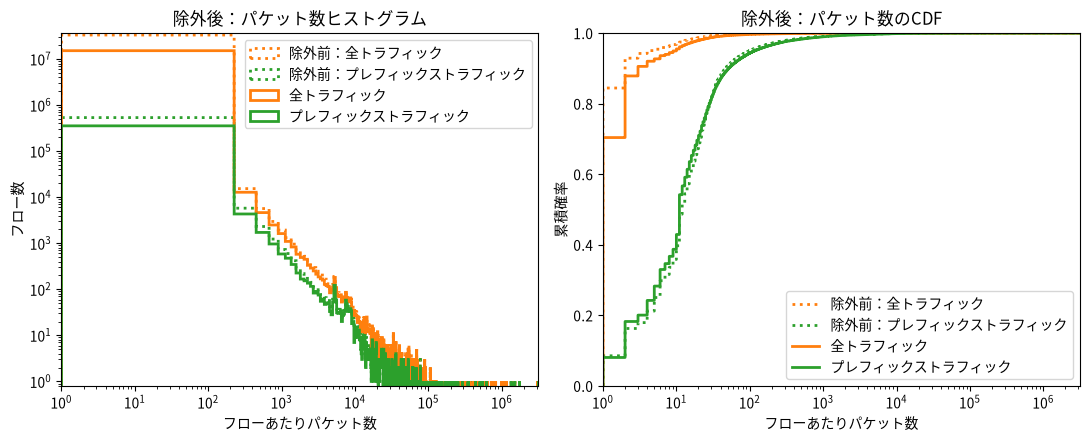

In [8]:
def ecdf(values):
    ordered = np.sort(np.asarray(values, dtype=float))
    return ordered, np.arange(1, len(ordered) + 1) / len(ordered)

protocols = {'TCP': ['6', '6.0', 'tcp'], 'UDP': ['17', '17.0', 'udp']}
packet_distribution_scopes = [('全トラフィック', ipv4_flows, '-'), ('プレフィックストラフィック', selected_scope_flows, '--')]
packet_cdf_scopes = [('全トラフィック', ipv4_flows, 'tab:orange', '-'), ('プレフィックストラフィック', selected_scope_flows, 'tab:green', '-')]

def packet_distribution_series(condition):
    inclusion_column = conditions.loc[conditions['condition'] == condition, 'inclusion_column'].iloc[0]
    series = []
    for protocol, values in protocols.items():
        for scope, frame, style in packet_distribution_scopes:
            packets = pd.to_numeric(
                frame.loc[frame[inclusion_column] & frame['protocol'].astype(str).isin(values), 'packet_count'],
                errors='coerce',
            ).dropna()
            series.append({'protocol': protocol, 'scope': scope, 'style': style, 'label': f'{protocol}: {scope}', 'packets': packets})
    return series

raw_packet_distribution_series = packet_distribution_series('Raw')
broad_packet_distribution_series = packet_distribution_series('Broad')

def packet_cdf_series(condition):
    inclusion_column = conditions.loc[conditions['condition'] == condition, 'inclusion_column'].iloc[0]
    series = []
    for scope, frame, color, style in packet_cdf_scopes:
        packets = pd.to_numeric(
            frame.loc[frame[inclusion_column] & frame['protocol'].astype(str).isin([*protocols['TCP'], *protocols['UDP']]), 'packet_count'],
            errors='coerce',
        ).dropna()
        series.append({'scope': scope, 'color': color, 'style': style, 'label': scope, 'packets': packets})
    return series

raw_packet_cdf_series = packet_cdf_series('Raw')
broad_packet_cdf_series = packet_cdf_series('Broad')
all_packet_counts = pd.concat([item['packets'] for item in [*raw_packet_cdf_series, *broad_packet_cdf_series] if not item['packets'].empty], ignore_index=True)
if all_packet_counts.empty:
    raise ValueError('Raw / Broadのpacket_count分布を描画できるflowがありません')
common_packet_bin_edges = np.histogram_bin_edges(all_packet_counts, bins='auto')
common_packet_x_limits = (float(all_packet_counts.min()), float(all_packet_counts.max()))
common_packet_histogram_max = max(
    (np.histogram(item['packets'], bins=common_packet_bin_edges)[0].max() for item in [*raw_packet_cdf_series, *broad_packet_cdf_series] if not item['packets'].empty),
    default=1,
)
common_packet_histogram_y_limits = (0.8, max(1.0, common_packet_histogram_max * 1.1))

def plot_packet_distribution(series, title_prefix, reference_series=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for item in reference_series or []:
        if item['packets'].empty:
            continue
        x, y = ecdf(item['packets'])
        axes[0].hist(item['packets'], bins=common_packet_bin_edges, histtype='step', linewidth=2, color=item['color'], linestyle=':', alpha=1.0, label=f'除外前：{item['label']}')
        axes[1].step(x, y, where='post', linewidth=2, color=item['color'], linestyle=':', alpha=1.0, label=f'除外前：{item['label']}')
    for item in series:
        if item['packets'].empty:
            continue
        x, y = ecdf(item['packets'])
        axes[0].hist(item['packets'], bins=common_packet_bin_edges, histtype='step', linewidth=2, color=item['color'], linestyle=item['style'], label=item['label'])
        axes[1].step(x, y, where='post', linewidth=2, color=item['color'], linestyle=item['style'], label=item['label'])
    axes[0].set(title=f'{title_prefix}：パケット数ヒストグラム', xlabel='フローあたりパケット数', ylabel='フロー数', xscale='log', yscale='log', xlim=common_packet_x_limits, ylim=common_packet_histogram_y_limits)
    axes[1].set(title=f'{title_prefix}：パケット数のCDF', xlabel='フローあたりパケット数', ylabel='累積確率', xscale='log', xlim=common_packet_x_limits, ylim=(0, 1))
    for axis in axes:
        axis.legend()
    fig.tight_layout()

plot_packet_distribution(raw_packet_cdf_series, '除外前')
plot_packet_distribution(broad_packet_cdf_series, '除外後', reference_series=raw_packet_cdf_series)

### 除外後のパケット数分布

Broad条件によるScan-like flow除外後について、全トラフィックとプレフィックストラフィックのpacket count分布を比較する。Rawで観測された分布差がBroad除外後にも維持されるかを確認する。

In [9]:
def packet_count_summary(condition, series):
    rows = []
    for item in series:
        packets = item['packets']
        rows.append({
            'condition': condition,
            'scope': item['scope'],
            'protocol': item['protocol'],
            'flow_count': len(packets),
            'median_packet_count': packets.median() if not packets.empty else np.nan,
            'q75_packet_count': packets.quantile(0.75) if not packets.empty else np.nan,
            'q90_packet_count': packets.quantile(0.90) if not packets.empty else np.nan,
            'q95_packet_count': packets.quantile(0.95) if not packets.empty else np.nan,
            'q99_packet_count': packets.quantile(0.99) if not packets.empty else np.nan,
            'one_packet_flow_ratio': (packets == 1).mean() if not packets.empty else np.nan,
        })
    return rows

packet_count_distribution_summary = pd.DataFrame([
    *packet_count_summary('Raw', raw_packet_distribution_series),
    *packet_count_summary('Broad', broad_packet_distribution_series),
])
display(packet_count_distribution_summary)

,condition,scope,protocol,flow_count,median_packet_count,q75_packet_count,q90_packet_count,q95_packet_count,q99_packet_count,one_packet_flow_ratio
0,Raw,全トラフィック,TCP,27602301,1.0,1.0,2.0,4.0,23.00,0.885566
1,Raw,プレフィックストラフィック,TCP,432429,13.0,25.0,45.0,91.0,687.00,0.068249
2,Raw,全トラフィック,UDP,5692831,1.0,2.0,2.0,5.0,35.00,0.644590
3,Raw,プレフィックストラフィック,UDP,117561,6.0,20.0,54.0,136.0,1297.00,0.148110
4,Broad,全トラフィック,TCP,9530142,1.0,2.0,4.0,11.0,36.00,0.739361
5,Broad,プレフィックストラフィック,TCP,248105,12.0,25.0,51.0,110.0,951.96,0.048488
6,Broad,全トラフィック,UDP,5692831,1.0,2.0,2.0,5.0,35.00,0.644590
7,Broad,プレフィックストラフィック,UDP,117561,6.0,20.0,54.0,136.0,1297.00,0.148110


### Raw / Broadのフレームバイト数ECDF

packet count ECDF と同じ IPv4・全トラフィック／プレフィックストラフィック・TCP/UDP・Raw/Broad の比較条件で、フローあたりの frame byte count 分布を確認する。


/tmp/ipykernel_198040/4077676419.py:81: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


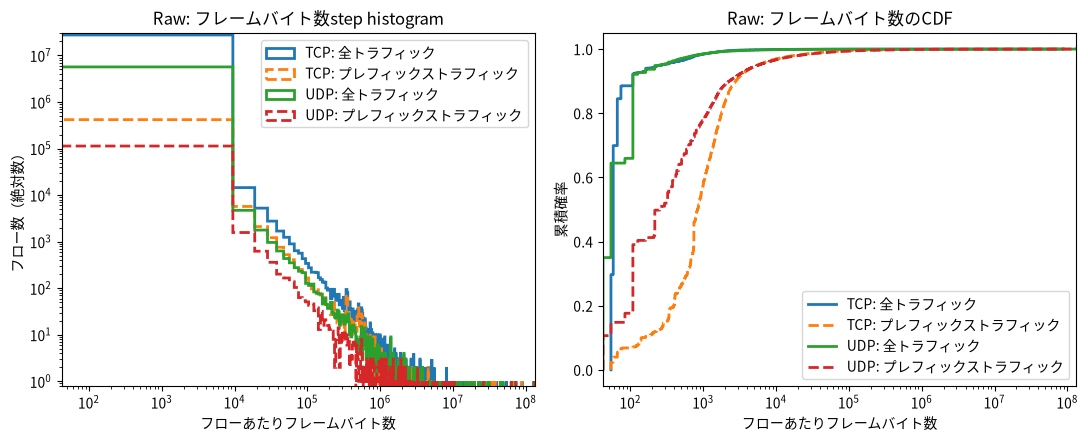

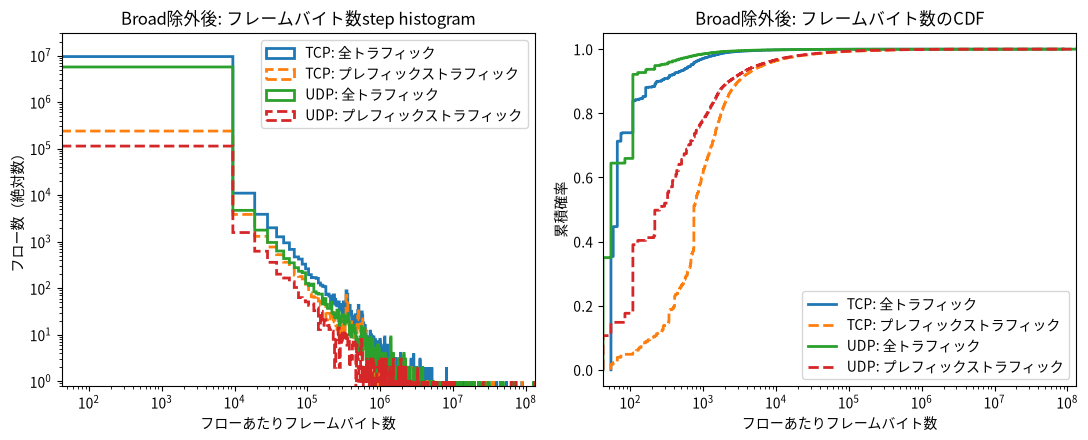

In [10]:
def frame_byte_distribution_series(condition):
    inclusion_column = conditions.loc[
        conditions['condition'] == condition, 'inclusion_column'
    ].iloc[0]
    series = []
    for protocol, values in protocols.items():
        for scope, frame, style in packet_distribution_scopes:
            frame_bytes = pd.to_numeric(
                frame.loc[
                    frame[inclusion_column]
                    & frame['protocol'].astype(str).isin(values),
                    'frame_byte_count',
                ],
                errors='coerce',
            ).dropna()
            series.append(
                {
                    'protocol': protocol,
                    'scope': scope,
                    'style': style,
                    'label': f'{protocol}: {scope}',
                    'frame_bytes': frame_bytes,
                }
            )
    return series

raw_frame_byte_distribution_series = frame_byte_distribution_series('Raw')
broad_frame_byte_distribution_series = frame_byte_distribution_series('Broad')
all_frame_byte_counts = pd.concat(
    [
        item['frame_bytes']
        for item in [
            *raw_frame_byte_distribution_series,
            *broad_frame_byte_distribution_series,
        ]
        if not item['frame_bytes'].empty
    ],
    ignore_index=True,
)
if all_frame_byte_counts.empty:
    raise ValueError('Raw / Broadのframe_byte_count分布を描画できるflowがありません')
if (all_frame_byte_counts <= 0).any():
    raise ValueError('対数軸のframe_byte_count分布には正の値が必要です')
common_frame_byte_bin_edges = np.histogram_bin_edges(all_frame_byte_counts, bins='auto')
common_frame_byte_x_limits = (
    float(all_frame_byte_counts.min()),
    float(all_frame_byte_counts.max()),
)
common_frame_byte_histogram_max = max(
    (np.histogram(item['frame_bytes'], bins=common_frame_byte_bin_edges)[0].max() for item in [*raw_frame_byte_distribution_series, *broad_frame_byte_distribution_series] if not item['frame_bytes'].empty),
    default=1,
)
common_frame_byte_histogram_y_limits = (0.8, max(1.0, common_frame_byte_histogram_max * 1.1))

def plot_frame_byte_distribution(series, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for item in series:
        if item['frame_bytes'].empty:
            continue
        x, y = ecdf(item['frame_bytes'])
        axes[0].hist(item['frame_bytes'], bins=common_frame_byte_bin_edges, histtype='step', linewidth=2, linestyle=item['style'], label=item['label'])
        axes[1].step(x, y, where='post', linewidth=2, linestyle=item['style'], label=item['label'])
    axes[0].set(
        title=f'{title_prefix}: フレームバイト数step histogram',
        xlabel='フローあたりフレームバイト数',
        ylabel='フロー数（絶対数）',
        xscale='log',
        yscale='log',
        xlim=common_frame_byte_x_limits,
        ylim=common_frame_byte_histogram_y_limits,
    )
    axes[1].set(
        title=f'{title_prefix}: フレームバイト数のCDF',
        xlabel='フローあたりフレームバイト数',
        ylabel='累積確率',
        xscale='log',
        xlim=common_frame_byte_x_limits,
    )
    for axis in axes:
        axis.legend()
    fig.tight_layout()

plot_frame_byte_distribution(raw_frame_byte_distribution_series, 'Raw')
plot_frame_byte_distribution(broad_frame_byte_distribution_series, 'Broad除外後')


,canonical membershipがゼロの選択済みプレフィックス数,選択済みプレフィックス数
0,0,18


,分析プレフィックス,プレフィックス長,srcプレフィックスとして観測,dstプレフィックスとして観測,フロー数,パケット数,フレームバイト数,IPバイト数,パケット数の中央値,フレームバイト数の中央値,継続時間の中央値,継続時間の90パーセンタイル,継続時間の99パーセンタイル
13,202.3.204.0/24,24,False,True,229548,24057826,1294747804,957938240,17.0,1006.0,0.810590,223.300856,840.105670
4,150.217.137.141/32,32,True,False,56460,7244587,463910070,362485852,11.0,742.0,1.395999,18.373334,840.156705
7,157.53.116.0/28,28,False,True,68451,6639201,343777554,250828740,9.0,510.0,0.642715,97.139827,771.090498
2,133.132.116.53/32,32,True,False,101180,5368842,293575728,218411940,13.0,804.0,1.201265,150.805117,840.149263
8,157.53.116.16/28,28,False,True,24877,4665385,229172786,163857396,8.0,470.0,0.562915,101.004357,753.541283
14,203.68.133.255/32,32,True,False,50116,3006832,198998512,156902864,11.0,742.0,0.081357,367.183676,788.587463
9,157.53.44.81/32,32,True,False,465,2866929,189220534,149083528,6604.0,435864.0,6.209449,6.561200,7.853359
11,172.41.213.92/32,32,False,True,3390,2850311,186353850,146449496,14.0,672.0,1.107490,305.120350,879.355268
10,163.29.158.43/32,32,True,False,289,2712887,178784914,140804496,17.0,888.0,3.132016,370.764742,803.999338
1,131.142.238.168/32,32,False,True,8801,3596059,157134894,106790068,10.0,528.0,1.718025,240.000565,714.261432


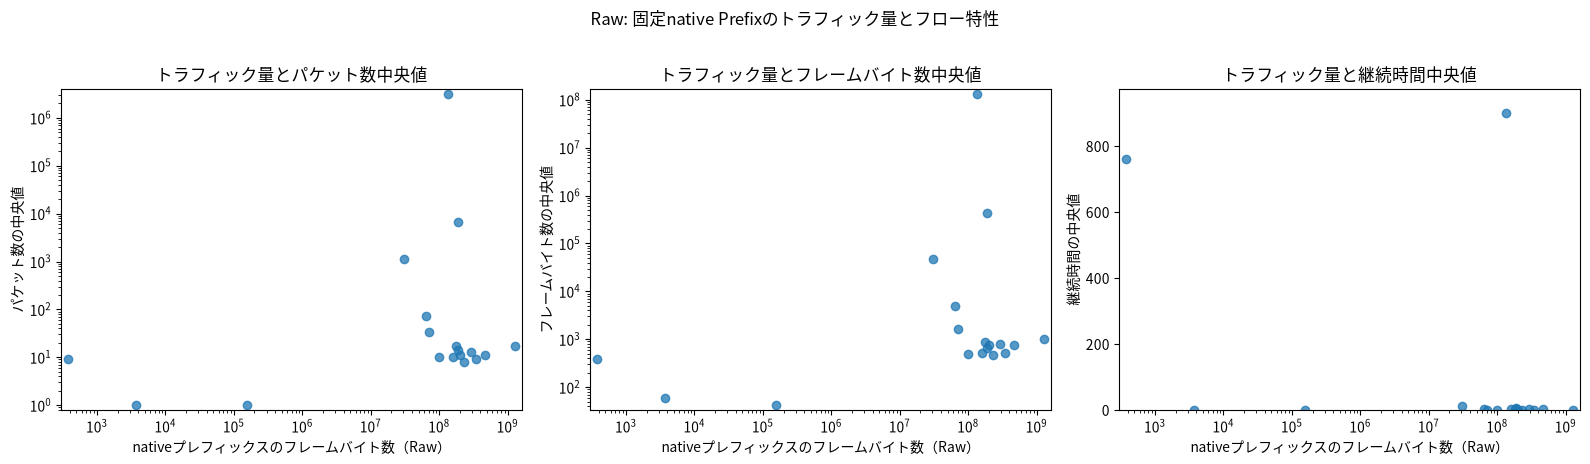

In [11]:
# canonical membershipがゼロのプレフィックスを含め、選択済みnativeプレフィックスごとに1行を保持する。
prefix_metrics = prefix_flows.groupby('analysis_prefix', as_index=False).agg(flow_count=('flow_id', 'size'), packet_count=('packet_count', 'sum'), frame_byte_count=('frame_byte_count', 'sum'), ip_byte_count=('ip_byte_count', 'sum'), median_packet_count=('packet_count', 'median'), median_frame_byte_count=('frame_byte_count', 'median'), median_duration=('duration', 'median'), q90_duration=('duration', lambda values: values.quantile(0.9)), q99_duration=('duration', lambda values: values.quantile(0.99)))
prefix_summary = selected_prefixes.rename(columns={'prefix': 'analysis_prefix'}).merge(prefix_metrics, on='analysis_prefix', how='left', validate='one_to_one')
zero_volume_prefixes = prefix_summary['flow_count'].isna()
prefix_summary[['flow_count', 'packet_count', 'frame_byte_count', 'ip_byte_count']] = prefix_summary[['flow_count', 'packet_count', 'frame_byte_count', 'ip_byte_count']].fillna(0)
display(pd.DataFrame([{'canonical membershipがゼロの選択済みプレフィックス数': int(zero_volume_prefixes.sum()), '選択済みプレフィックス数': len(prefix_summary)}]))
display_table(prefix_summary.sort_values('frame_byte_count', ascending=False).head(20))

# Raw/Broadで同じ軸範囲を使うため、ここでは固定Prefix集合に対するBroad集計を軸計算だけに用いる。
broad_axis_metrics = prefix_flows.loc[prefix_flows['broad_included'] == True].groupby('analysis_prefix', as_index=False).agg(frame_byte_count=('frame_byte_count', 'sum'), median_packet_count=('packet_count', 'median'), median_frame_byte_count=('frame_byte_count', 'median'), median_duration=('duration', 'median'))
broad_axis_summary = selected_prefixes.rename(columns={'prefix': 'analysis_prefix'}).loc[:, ['analysis_prefix']].merge(broad_axis_metrics, on='analysis_prefix', how='left', validate='one_to_one').fillna({'frame_byte_count': 0})
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for axis, y_column, title, log_y in zip(axes, ['median_packet_count', 'median_frame_byte_count', 'median_duration'], ['トラフィック量とパケット数中央値', 'トラフィック量とフレームバイト数中央値', 'トラフィック量と継続時間中央値'], [True, True, False]):
    plotted = prefix_summary.loc[(prefix_summary['frame_byte_count'] > 0) & prefix_summary[y_column].notna()]
    if log_y:
        plotted = plotted.loc[plotted[y_column] > 0]
    combined = pd.concat([prefix_summary[['frame_byte_count', y_column]], broad_axis_summary[['frame_byte_count', y_column]]], ignore_index=True)
    x_values = combined.loc[combined['frame_byte_count'] > 0, 'frame_byte_count'].dropna()
    y_values = combined.loc[combined[y_column] > 0, y_column].dropna() if log_y else combined[y_column].dropna()
    axis.scatter(plotted['frame_byte_count'], plotted[y_column], alpha=0.75, color='tab:blue')
    if not x_values.empty and not y_values.empty:
        axis.set_xlim(x_values.min() / 1.25, x_values.max() * 1.25)
        if log_y:
            axis.set_ylim(y_values.min() / 1.25, y_values.max() * 1.25)
        else:
            padding = max((y_values.max() - y_values.min()) * 0.08, 1e-9)
            axis.set_ylim(max(0, y_values.min() - padding), y_values.max() + padding)
    axis.set(xscale='log', yscale='log' if log_y else 'linear', xlabel='nativeプレフィックスのフレームバイト数（Raw）', ylabel=display_column_names[y_column], title=title)
fig.suptitle('Raw: 固定native Prefixのトラフィック量とフロー特性', y=1.02)
fig.tight_layout()

### Broad除外後のトラフィック量とフロー特性

Rawで選択済みのnative `analysis_prefix` 集合を固定したまま、`broad_included == True` のflowだけで集計する。Broad後にflowが残らないPrefixもsummaryには残し、countは0、中央値と分位点は`NaN`とする。

,分析プレフィックス,プレフィックス長,srcプレフィックスとして観測,dstプレフィックスとして観測,フロー数,パケット数,フレームバイト数,IPバイト数,パケット数の中央値,フレームバイト数の中央値,継続時間の中央値,継続時間の90パーセンタイル,継続時間の99パーセンタイル
13,202.3.204.0/24,24,False,True,162398,20103571,1043668746,762218752,14.0,834.0,1.067514,306.333589,856.100253
4,150.217.137.141/32,32,True,False,50017,5516958,354130716,276893304,11.0,742.0,1.170809,18.532185,840.176148
7,157.53.116.0/28,28,False,True,44661,6188868,315357360,228713208,9.0,504.0,0.599327,116.532792,843.094907
8,157.53.116.16/28,28,False,True,15929,4470043,216513198,153932596,8.0,436.0,0.381309,117.861445,840.795981
9,157.53.44.81/32,32,True,False,465,2866929,189220534,149083528,6604.0,435864.0,6.209449,6.561200,7.853359
2,133.132.116.53/32,32,True,False,38872,3585431,176006630,125810596,14.0,630.0,0.674773,241.982147,881.664908
1,131.142.238.168/32,32,False,True,8010,3558354,155021232,105204276,9.0,498.0,1.486954,240.305187,719.999991
17,217.214.203.22/32,32,True,False,1,3156783,132584886,88389924,3156783.0,132584886.0,899.568959,899.568959,899.568959
14,203.68.133.255/32,32,True,False,36368,1642827,108972674,85973096,11.0,742.0,0.053897,5.343824,637.933557
0,131.142.206.160/32,32,False,True,898,2031684,97590112,69146536,10.0,498.0,0.331564,241.675411,879.791969


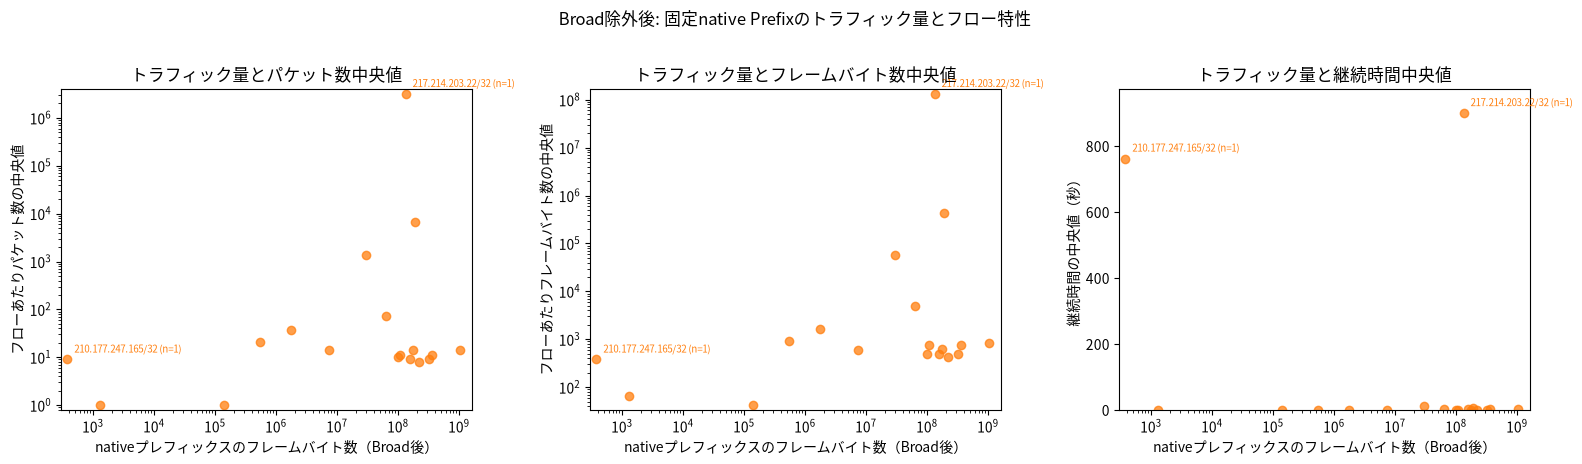

In [12]:
prefix_summary_columns = ['flow_count', 'packet_count', 'frame_byte_count', 'ip_byte_count']
prefix_feature_columns = ['median_packet_count', 'median_frame_byte_count', 'median_duration', 'q90_duration', 'q99_duration']

def fixed_prefix_summary(surviving_prefix_flows):
    aggregated = surviving_prefix_flows.groupby('analysis_prefix', as_index=False).agg(
        flow_count=('flow_id', 'size'),
        packet_count=('packet_count', 'sum'),
        frame_byte_count=('frame_byte_count', 'sum'),
        ip_byte_count=('ip_byte_count', 'sum'),
        median_packet_count=('packet_count', 'median'),
        median_frame_byte_count=('frame_byte_count', 'median'),
        median_duration=('duration', 'median'),
        q90_duration=('duration', lambda values: values.quantile(0.9)),
        q99_duration=('duration', lambda values: values.quantile(0.99)),
    )
    summary = selected_prefixes.rename(columns={'prefix': 'analysis_prefix'}).merge(
        aggregated, on='analysis_prefix', how='left', validate='one_to_one'
    )
    summary[prefix_summary_columns] = summary[prefix_summary_columns].fillna(0)
    return summary

broad_prefix_summary = fixed_prefix_summary(prefix_flows.loc[prefix_flows['broad_included'] == True])
if set(broad_prefix_summary['analysis_prefix']) != set(prefix_summary['analysis_prefix']):
    raise ValueError('Broad summaryがRaw由来の固定native Prefix集合を保持していません')
display_table(broad_prefix_summary.sort_values('frame_byte_count', ascending=False).head(20))

scatter_specs = [
    ('median_packet_count', 'トラフィック量とパケット数中央値', 'フローあたりパケット数の中央値', True),
    ('median_frame_byte_count', 'トラフィック量とフレームバイト数中央値', 'フローあたりフレームバイト数の中央値', True),
    ('median_duration', 'トラフィック量と継続時間中央値', '継続時間の中央値（秒）', False),
]

def common_scatter_limits(raw_summary, broad_summary, y_column, log_y):
    combined = pd.concat([raw_summary[['frame_byte_count', y_column]], broad_summary[['frame_byte_count', y_column]]], ignore_index=True)
    x_values = combined.loc[combined['frame_byte_count'] > 0, 'frame_byte_count'].dropna()
    y_values = combined.loc[combined[y_column] > 0, y_column].dropna() if log_y else combined[y_column].dropna()
    if x_values.empty or y_values.empty:
        return None
    x_limits = (x_values.min() / 1.25, x_values.max() * 1.25)
    if log_y:
        y_limits = (y_values.min() / 1.25, y_values.max() * 1.25)
    else:
        padding = max((y_values.max() - y_values.min()) * 0.08, 1e-9)
        y_limits = (max(0, y_values.min() - padding), y_values.max() + padding)
    return x_limits, y_limits

def annotate_small_prefixes(axis, summary, y_column, color):
    for row in summary.loc[(summary['flow_count'] <= 10) & (summary['flow_count'] > 0) & (summary['frame_byte_count'] > 0) & summary[y_column].notna()].itertuples(index=False):
        axis.annotate(f'{row.analysis_prefix} (n={int(row.flow_count)})', (row.frame_byte_count, getattr(row, y_column)), xytext=(5, 5), textcoords='offset points', fontsize=7, color=color)

common_scatter_axes = {y_column: common_scatter_limits(prefix_summary, broad_prefix_summary, y_column, log_y) for y_column, _, _, log_y in scatter_specs}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for axis, (y_column, title, y_label, log_y) in zip(axes, scatter_specs):
    plotted = broad_prefix_summary.loc[(broad_prefix_summary['frame_byte_count'] > 0) & broad_prefix_summary[y_column].notna()]
    if log_y:
        plotted = plotted.loc[plotted[y_column] > 0]
    axis.scatter(plotted['frame_byte_count'], plotted[y_column], alpha=0.75, color='tab:orange')
    annotate_small_prefixes(axis, plotted, y_column, 'tab:orange')
    limits = common_scatter_axes[y_column]
    if limits is not None:
        axis.set_xlim(*limits[0])
        axis.set_ylim(*limits[1])
    axis.set(xscale='log', yscale='log' if log_y else 'linear', xlabel='nativeプレフィックスのフレームバイト数（Broad後）', ylabel=y_label, title=title)
fig.suptitle('Broad除外後: 固定native Prefixのトラフィック量とフロー特性', y=1.02)
fig.tight_layout()

### RawからBroadへのプレフィックス位置の変化

同じRaw由来の固定native Prefixについて、Raw点とBroad点を接続する。Broad後にflowが残らず中央値が未定義のPrefixは、0へ接続せず比較対象外とする。

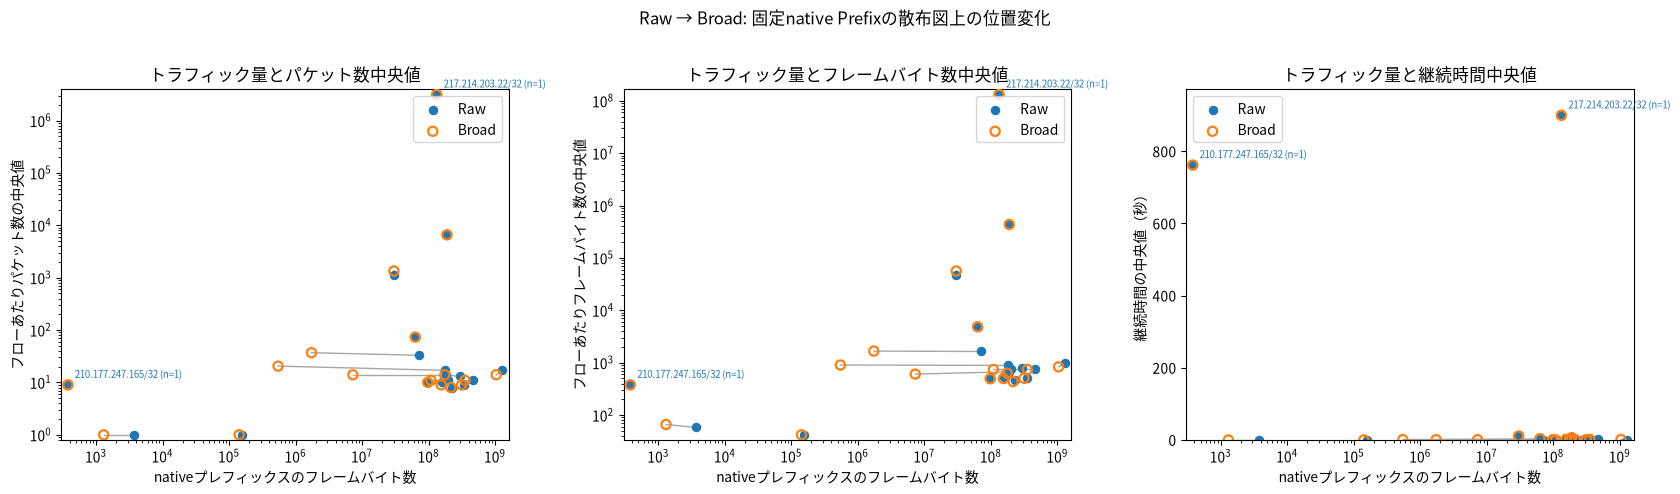

In [13]:
raw_broad_prefix_summary = prefix_summary.merge(
    broad_prefix_summary, on=['analysis_prefix', 'prefix_length'], how='inner', suffixes=('_raw', '_broad'), validate='one_to_one'
)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for axis, (y_column, title, y_label, log_y) in zip(axes, scatter_specs):
    raw_x = 'frame_byte_count_raw'
    broad_x = 'frame_byte_count_broad'
    raw_y = f'{y_column}_raw'
    broad_y = f'{y_column}_broad'
    comparable = raw_broad_prefix_summary.loc[
        (raw_broad_prefix_summary[raw_x] > 0) & (raw_broad_prefix_summary[broad_x] > 0)
        & raw_broad_prefix_summary[raw_y].notna() & raw_broad_prefix_summary[broad_y].notna()
    ].copy()
    if log_y:
        comparable = comparable.loc[(comparable[raw_y] > 0) & (comparable[broad_y] > 0)]
    for row in comparable.itertuples(index=False):
        axis.plot([getattr(row, raw_x), getattr(row, broad_x)], [getattr(row, raw_y), getattr(row, broad_y)], color='0.65', linewidth=1, zorder=1)
    axis.scatter(comparable[raw_x], comparable[raw_y], color='tab:blue', s=34, label='Raw', zorder=2)
    axis.scatter(comparable[broad_x], comparable[broad_y], facecolors='none', edgecolors='tab:orange', linewidths=1.6, s=44, label='Broad', zorder=3)
    for row in comparable.loc[(comparable['flow_count_raw'] <= 10) | (comparable['flow_count_broad'] <= 10)].itertuples(index=False):
        axis.annotate(f'{row.analysis_prefix} (n={int(row.flow_count_raw)})', (getattr(row, raw_x), getattr(row, raw_y)), xytext=(5, 5), textcoords='offset points', fontsize=7, color='tab:blue')
    limits = common_scatter_axes[y_column]
    if limits is not None:
        axis.set_xlim(*limits[0])
        axis.set_ylim(*limits[1])
    axis.set(xscale='log', yscale='log' if log_y else 'linear', xlabel='nativeプレフィックスのフレームバイト数', ylabel=y_label, title=title)
    axis.legend()
fig.suptitle('Raw → Broad: 固定native Prefixの散布図上の位置変化', y=1.02)
fig.tight_layout()

### Raw / Broad 数値比較表

除外率はRawを分母とする。Rawの分母が0の場合は無限大ではなく`NaN`とする。

In [14]:
prefix_raw_broad_comparison = raw_broad_prefix_summary.loc[:, [
    'analysis_prefix', 'prefix_length',
    'flow_count_raw', 'flow_count_broad',
    'frame_byte_count_raw', 'frame_byte_count_broad',
    'median_packet_count_raw', 'median_packet_count_broad',
    'median_frame_byte_count_raw', 'median_frame_byte_count_broad',
    'median_duration_raw', 'median_duration_broad',
]].rename(columns={
    'flow_count_raw': 'raw_flow_count', 'flow_count_broad': 'broad_flow_count',
    'frame_byte_count_raw': 'raw_frame_byte_count', 'frame_byte_count_broad': 'broad_frame_byte_count',
    'median_packet_count_raw': 'raw_median_packet_count', 'median_packet_count_broad': 'broad_median_packet_count',
    'median_frame_byte_count_raw': 'raw_median_frame_byte_count', 'median_frame_byte_count_broad': 'broad_median_frame_byte_count',
    'median_duration_raw': 'raw_median_duration', 'median_duration_broad': 'broad_median_duration',
})
prefix_raw_broad_comparison['flow_removal_rate'] = safe_ratio(
    prefix_raw_broad_comparison['raw_flow_count'] - prefix_raw_broad_comparison['broad_flow_count'],
    prefix_raw_broad_comparison['raw_flow_count'],
)
prefix_raw_broad_comparison['frame_byte_volume_removal_rate'] = safe_ratio(
    prefix_raw_broad_comparison['raw_frame_byte_count'] - prefix_raw_broad_comparison['broad_frame_byte_count'],
    prefix_raw_broad_comparison['raw_frame_byte_count'],
)
comparison_columns = [
    'analysis_prefix', 'prefix_length',
    'raw_flow_count', 'broad_flow_count', 'flow_removal_rate',
    'raw_frame_byte_count', 'broad_frame_byte_count', 'frame_byte_volume_removal_rate',
    'raw_median_packet_count', 'broad_median_packet_count',
    'raw_median_frame_byte_count', 'broad_median_frame_byte_count',
    'raw_median_duration', 'broad_median_duration',
]
display(prefix_raw_broad_comparison.loc[:, comparison_columns].sort_values('analysis_prefix'))

,analysis_prefix,prefix_length,raw_flow_count,broad_flow_count,flow_removal_rate,raw_frame_byte_count,broad_frame_byte_count,frame_byte_volume_removal_rate,raw_median_packet_count,broad_median_packet_count,raw_median_frame_byte_count,broad_median_frame_byte_count,raw_median_duration,broad_median_duration
0,131.142.206.160/32,32,994,898,0.096579,97684112,97590112,0.000962,10.0,10.0,498.0,498.0,0.413736,0.331564
1,131.142.238.168/32,32,8801,8010,0.089876,157134894,155021232,0.013451,10.0,9.0,528.0,498.0,1.718025,1.486954
2,133.132.116.53/32,32,101180,38872,0.615813,293575728,176006630,0.400473,13.0,14.0,804.0,630.0,1.201265,0.674773
3,142.11.234.5/32,32,592,471,0.204392,70939490,1737838,0.975503,33.0,37.0,1638.0,1666.0,0.430655,0.465926
4,150.217.137.141/32,32,56460,50017,0.114116,463910070,354130716,0.236639,11.0,11.0,742.0,742.0,1.395999,1.170809
5,150.217.140.38/32,32,59,17,0.711864,3738,1306,0.650615,1.0,1.0,58.0,66.0,0.000000,0.000000
6,151.34.117.44/32,32,1819,1818,0.000550,63176166,63168304,0.000124,74.0,73.5,4892.0,4859.0,3.370416,3.368901
7,157.53.116.0/28,28,68451,44661,0.347548,343777554,315357360,0.082670,9.0,9.0,510.0,504.0,0.642715,0.599327
8,157.53.116.16/28,28,24877,15929,0.359690,229172786,216513198,0.055240,8.0,8.0,470.0,436.0,0.562915,0.381309
9,157.53.44.81/32,32,465,465,0.000000,189220534,189220534,0.000000,6604.0,6604.0,435864.0,435864.0,6.209449,6.209449


### Rawのフロー継続時間分布

Rawで観測された全トラフィックと、Raw時点で固定されたプレフィックストラフィックのduration分布を示す。step histogramはduration帯ごとの**絶対flow数**を確認する補助図であり、母集団サイズを正規化して分布そのものを比較する主図はECDFである。

durationはcapture内で観測されたfirst packetとlast packetの時間差であり、capture開始前またはcapture終了後にも通信が継続している場合、真のflow継続時間とは一致しない。900秒近傍の値は15分観測窓による打ち切りの影響を受け得る。Broad除外後もOverallとNativeのduration分布差が維持されるかを確認する。

/tmp/ipykernel_198040/216709892.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


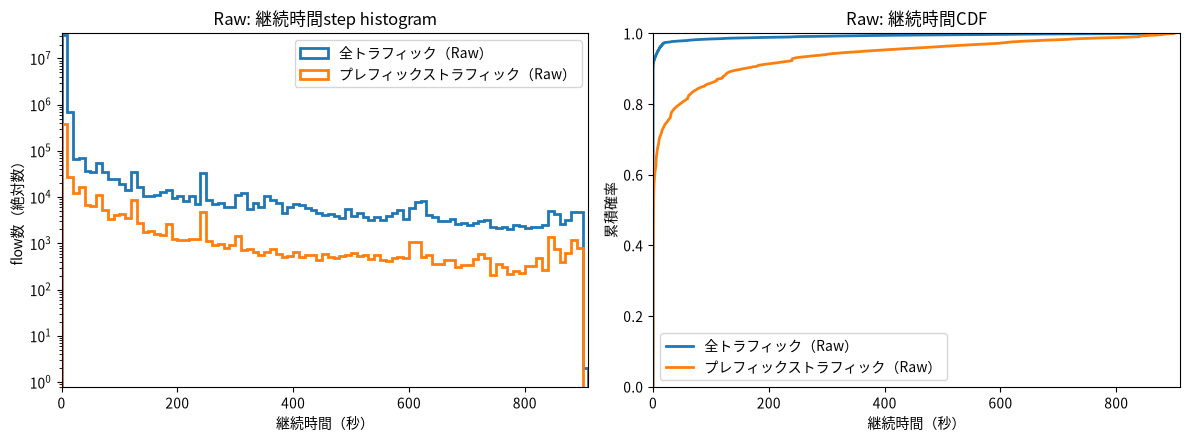

In [15]:
# Native BroadはRaw由来の固定membership集合から、Broadで残存したflowだけを選ぶ。
duration_series = {
    'overall_raw': {'condition': 'Raw', 'scope': 'Overall', 'label': '全トラフィック（Raw）', 'color': 'tab:blue', 'linestyle': '-', 'values': raw_flows['duration'].dropna()},
    'overall_broad': {'condition': 'Broad', 'scope': 'Overall', 'label': '全トラフィック（Broad）', 'color': 'tab:blue', 'linestyle': '--', 'values': raw_flows.loc[raw_flows['broad_included'] == True, 'duration'].dropna()},
    'native_raw': {'condition': 'Raw', 'scope': 'Native', 'label': 'プレフィックストラフィック（Raw）', 'color': 'tab:orange', 'linestyle': '-', 'values': selected_scope_flows['duration'].dropna()},
    'native_broad': {'condition': 'Broad', 'scope': 'Native', 'label': 'プレフィックストラフィック（Broad）', 'color': 'tab:orange', 'linestyle': '--', 'values': selected_scope_flows.loc[selected_scope_flows['broad_included'] == True, 'duration'].dropna()},
}

# 全4系列で同じ0秒起点・10秒幅のbinを使い、Raw/Broad間でhistogramを直接比較できるようにする。
DURATION_HISTOGRAM_BIN_WIDTH_SECONDS = 10
nonempty_duration_series = [series['values'] for series in duration_series.values() if not series['values'].empty]
if not nonempty_duration_series:
    raise ValueError('duration分布を描画できるflowがありません')
all_durations = pd.concat(nonempty_duration_series, ignore_index=True)
max_duration = float(all_durations.max())
duration_xmax = max(DURATION_HISTOGRAM_BIN_WIDTH_SECONDS, max_duration)
duration_bin_edges = np.arange(0, duration_xmax + DURATION_HISTOGRAM_BIN_WIDTH_SECONDS, DURATION_HISTOGRAM_BIN_WIDTH_SECONDS, dtype=float)
if duration_bin_edges[-1] < duration_xmax:
    duration_bin_edges = np.append(duration_bin_edges, duration_xmax)
duration_x_limits = (0, duration_bin_edges[-1])
duration_histogram_max = max((np.histogram(series['values'], bins=duration_bin_edges)[0].max() for series in duration_series.values() if not series['values'].empty), default=1)
duration_histogram_y_limits = (0.8, max(1.0, duration_histogram_max * 1.1))

def plot_duration_distribution(series_keys, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for key in series_keys:
        series = duration_series[key]
        values = series['values']
        if values.empty:
            continue
        axes[0].hist(values, bins=duration_bin_edges, histtype='step', linewidth=2, color=series['color'], linestyle=series['linestyle'], label=series['label'])
        x, y = ecdf(values)
        axes[1].step(x, y, where='post', linewidth=2, color=series['color'], linestyle=series['linestyle'], label=series['label'])
    axes[0].set(title=f'{title_prefix}: 継続時間step histogram', xlabel='継続時間（秒）', ylabel='flow数（絶対数）', xlim=duration_x_limits, ylim=duration_histogram_y_limits, yscale='log')
    axes[1].set(title=f'{title_prefix}: 継続時間CDF', xlabel='継続時間（秒）', ylabel='累積確率', xlim=duration_x_limits, ylim=(0, 1))
    for axis in axes:
        axis.legend()
    fig.tight_layout()

plot_duration_distribution(['overall_raw', 'native_raw'], 'Raw')

### Broad除外後のフロー継続時間分布

Rawで固定したnative Prefixのmembership集合をそのまま使い、その中で`broad_included == True`のflowだけをNative Broadとして比較する。

/tmp/ipykernel_198040/216709892.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


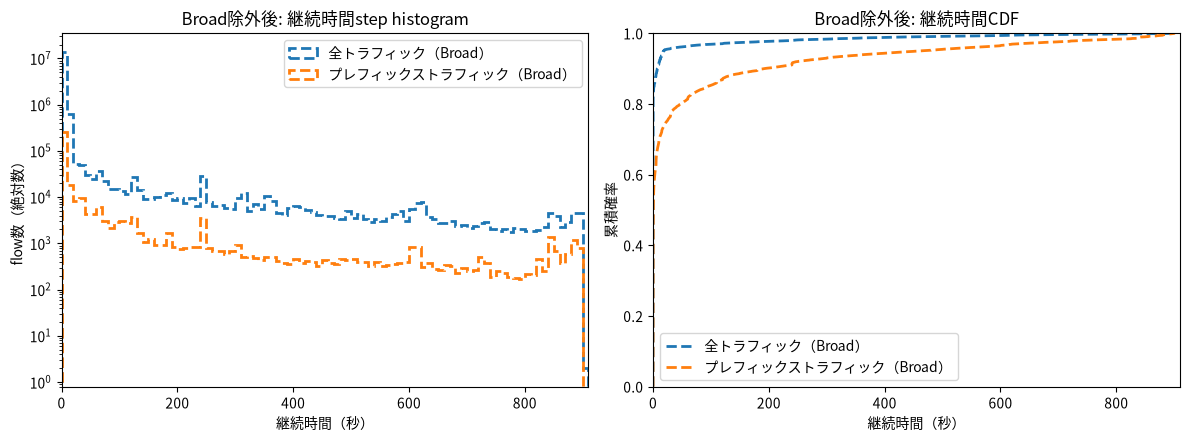

In [16]:
plot_duration_distribution(['overall_broad', 'native_broad'], 'Broad除外後')

### RawとBroadのフロー継続時間分布比較

同じscopeは同じ色、Raw/Broadは実線/破線で区別する。3図は同じbin edgesと軸範囲を使用する。

/tmp/ipykernel_198040/216709892.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


,condition,scope,flow_count,median_duration,q75_duration,q90_duration,q95_duration,q99_duration,zero_duration_ratio,duration_ge_1s_ratio,duration_ge_10s_ratio,duration_ge_100s_ratio
0,Raw,Overall,33295132,0.000000,0.000000,0.191040,8.197659,240.276533,0.844363,0.084430,0.046850,0.016003
1,Broad,Overall,15222973,0.000000,0.001482,7.450263,18.432031,446.181174,0.703920,0.162592,0.088240,0.030973
2,Raw,Native,549990,0.769498,24.678945,156.517094,369.759664,827.292695,0.085320,0.474214,0.309724,0.140817
3,Broad,Native,365666,0.549687,23.346274,191.285640,458.651681,849.263764,0.080516,0.459778,0.309017,0.147205


,scope,raw_flow_count,broad_flow_count,raw_median_duration,broad_median_duration,median_duration_delta,raw_q90_duration,broad_q90_duration,q90_duration_delta,raw_q99_duration,broad_q99_duration,q99_duration_delta,raw_zero_duration_ratio,broad_zero_duration_ratio,zero_duration_ratio_delta
0,Native,549990,365666,0.769498,0.549687,-0.219811,156.517094,191.285640,34.768546,827.292695,849.263764,21.971070,0.085320,0.080516,-0.004804
1,Overall,33295132,15222973,0.000000,0.000000,0.000000,0.191040,7.450263,7.259223,240.276533,446.181174,205.904641,0.844363,0.703920,-0.140443


/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


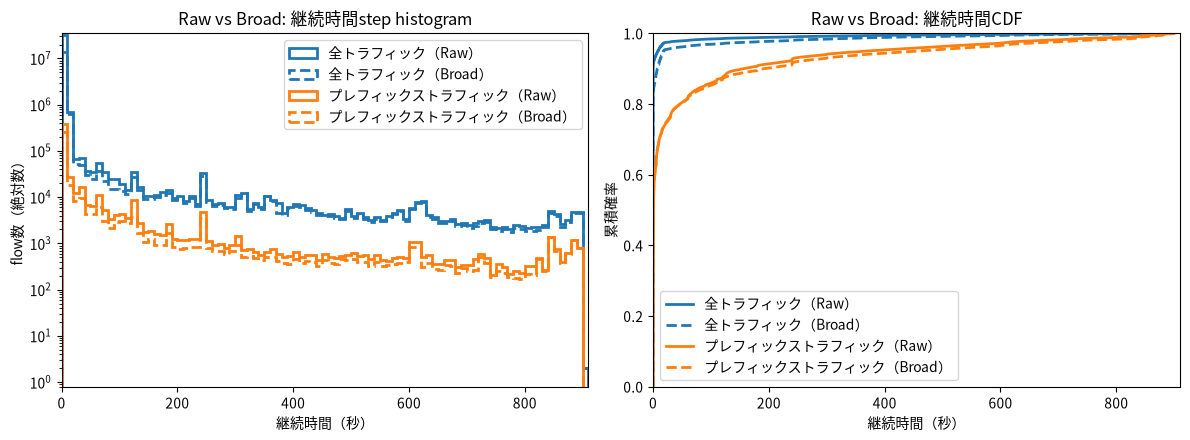

In [17]:
plot_duration_distribution(['overall_raw', 'overall_broad', 'native_raw', 'native_broad'], 'Raw vs Broad')

def duration_summary_row(series):
    values = series['values']
    flow_count = len(values)
    return {
        'condition': series['condition'],
        'scope': series['scope'],
        'flow_count': flow_count,
        'median_duration': values.median() if flow_count else np.nan,
        'q75_duration': values.quantile(0.75) if flow_count else np.nan,
        'q90_duration': values.quantile(0.90) if flow_count else np.nan,
        'q95_duration': values.quantile(0.95) if flow_count else np.nan,
        'q99_duration': values.quantile(0.99) if flow_count else np.nan,
        'zero_duration_ratio': (values == 0).mean() if flow_count else np.nan,
        'duration_ge_1s_ratio': (values >= 1).mean() if flow_count else np.nan,
        'duration_ge_10s_ratio': (values >= 10).mean() if flow_count else np.nan,
        'duration_ge_100s_ratio': (values >= 100).mean() if flow_count else np.nan,
    }

duration_summary = pd.DataFrame([duration_summary_row(duration_series[key]) for key in ['overall_raw', 'overall_broad', 'native_raw', 'native_broad']])
display(duration_summary)

raw_broad_duration_comparison = duration_summary.pivot(index='scope', columns='condition')
duration_change_summary = pd.DataFrame({
    'scope': raw_broad_duration_comparison.index,
    'raw_flow_count': raw_broad_duration_comparison[('flow_count', 'Raw')].to_numpy(),
    'broad_flow_count': raw_broad_duration_comparison[('flow_count', 'Broad')].to_numpy(),
    'raw_median_duration': raw_broad_duration_comparison[('median_duration', 'Raw')].to_numpy(),
    'broad_median_duration': raw_broad_duration_comparison[('median_duration', 'Broad')].to_numpy(),
    'raw_q90_duration': raw_broad_duration_comparison[('q90_duration', 'Raw')].to_numpy(),
    'broad_q90_duration': raw_broad_duration_comparison[('q90_duration', 'Broad')].to_numpy(),
    'raw_q99_duration': raw_broad_duration_comparison[('q99_duration', 'Raw')].to_numpy(),
    'broad_q99_duration': raw_broad_duration_comparison[('q99_duration', 'Broad')].to_numpy(),
    'raw_zero_duration_ratio': raw_broad_duration_comparison[('zero_duration_ratio', 'Raw')].to_numpy(),
    'broad_zero_duration_ratio': raw_broad_duration_comparison[('zero_duration_ratio', 'Broad')].to_numpy(),
})
duration_change_summary['median_duration_delta'] = duration_change_summary['broad_median_duration'] - duration_change_summary['raw_median_duration']
duration_change_summary['q90_duration_delta'] = duration_change_summary['broad_q90_duration'] - duration_change_summary['raw_q90_duration']
duration_change_summary['q99_duration_delta'] = duration_change_summary['broad_q99_duration'] - duration_change_summary['raw_q99_duration']
duration_change_summary['zero_duration_ratio_delta'] = duration_change_summary['broad_zero_duration_ratio'] - duration_change_summary['raw_zero_duration_ratio']
duration_comparison_columns = [
    'scope', 'raw_flow_count', 'broad_flow_count',
    'raw_median_duration', 'broad_median_duration', 'median_duration_delta',
    'raw_q90_duration', 'broad_q90_duration', 'q90_duration_delta',
    'raw_q99_duration', 'broad_q99_duration', 'q99_duration_delta',
    'raw_zero_duration_ratio', 'broad_zero_duration_ratio', 'zero_duration_ratio_delta',
]
display(duration_change_summary.loc[:, duration_comparison_columns])

この修正済みベースラインでは、選択された重複しないすべてのnative IPv4プレフィックスを意図的に使用します。prefix membershipは `src_ip ∈ prefix OR dst_ip ∈ prefix` とし、`src_match` と `dst_match` はトラフィックの役割ではなく観測方向の事実として保持します。